<h1 style="margin-bottom:3px;">System Development for FinTech</h1>
<h4 style="margin-bottom:2px;">Master Digital Driven Business</h4>

<h3 style="margin-bottom:3px;">Students – Group 5</h3>
Rümeysa Çelik  500984016 <br>
Ričards Kondrovs 500881697 <br>

<h3 style="margin-bottom:5px;">Project Description</h3>
The project uses the SAML-D dataset available on Kaggle, which contains more than 9.5 million synthetic financial transactions designed for anti-money laundering research. The dataset includes information about transaction time, sender and receiver accounts, transaction amounts, payment types, currencies, and bank locations.  
The aim of this project is to analyze transaction patterns and identify characteristics that are associated with money laundering activities. Using exploratory data analysis and machine learning models. In this project we detect suspicious transactions and understand the behavioral patterns that distinguish laundering activity from normal financial behavior.

<h3 style="margin-bottom:5px;">Business Question</h3>
Which transaction characteristics and behavioral patterns are the strongest indicators of money laundering in the banking system according to the information provided in the SAML-D dataset?

<h3 style="margin-bottom:5px;">Sub-questions</h3>

1. Which transaction characteristics such as amount size, payment method, currency differences, and cross-border transfers are most associated with money laundering transactions?

2. How do the behavioral patterns of accounts involved in money laundering differ from normal accounts in terms of transaction frequency, repetition, and transaction amounts?

3. Which machine learning model best detects money laundering transactions based on the identified transaction characteristics and behavioral patterns?

## 0. Project Setup

In [2]:
# Imports

# Core libraries
import pandas as pd
import numpy as np
import math
import shap
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns

# ML and Statistics
from scipy.stats import skew
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
    f1_score,
    ConfusionMatrixDisplay
)

# Model
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Utilities
from PIL import Image
from matplotlib.transforms import Bbox
from IPython.display import clear_output

# Visualization
plt.style.use("seaborn-v0_8")
sns.set_palette("deep")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

print("Setup has been completed")

Setup has been completed


## 1. Data Understanding

In [3]:
# In this section we develop an understanding of the dataset
df = pd.read_csv('SAML-D.csv')
df

,Time,Date,Sender_account,Receiver_account,Amount,Payment_currency,Received_currency,Sender_bank_location,Receiver_bank_location,Payment_type,Is_laundering,Laundering_type
0,10:35:19,2022-10-07,8724731955,2769355426,1459.1500,UK pounds,UK pounds,UK,UK,Cash Deposit,0,Normal_Cash_Deposits
1,10:35:20,2022-10-07,1491989064,8401255335,6019.6400,UK pounds,Dirham,UK,UAE,Cross-border,0,Normal_Fan_Out
2,10:35:20,2022-10-07,287305149,4404767002,14328.4400,UK pounds,UK pounds,UK,UK,Cheque,0,Normal_Small_Fan_Out
3,10:35:21,2022-10-07,5376652437,9600420220,11895.0000,UK pounds,UK pounds,UK,UK,ACH,0,Normal_Fan_In
4,10:35:21,2022-10-07,9614186178,3803336972,115.2500,UK pounds,UK pounds,UK,UK,Cash Deposit,0,Normal_Cash_Deposits
...,...,...,...,...,...,...,...,...,...,...,...,...
9504847,10:57:01,2023-08-23,2453933570,519744068,2247.2500,UK pounds,UK pounds,UK,UK,ACH,0,Normal_Small_Fan_Out
9504848,10:57:06,2023-08-23,9805510177,5416607878,927.1800,UK pounds,UK pounds,UK,UK,Debit card,0,Normal_Small_Fan_Out
9504849,10:57:06,2023-08-23,7282330957,2995527149,1455.1400,UK pounds,UK pounds,UK,UK,ACH,0,Normal_Small_Fan_Out
9504850,10:57:11,2023-08-23,940337377,4812815165,25995.7000,UK pounds,UK pounds,UK,UK,ACH,0,Normal_Fan_In


In [4]:
# See the shape of the dataset, column names and the data types we have SAML-D dataset
print("Shape of dataset:")
print(df.shape)

print("\nColumn names:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

Shape of dataset:
(9504852, 12)

Column names:
Index(['Time', 'Date', 'Sender_account', 'Receiver_account', 'Amount',
       'Payment_currency', 'Received_currency', 'Sender_bank_location',
       'Receiver_bank_location', 'Payment_type', 'Is_laundering',
       'Laundering_type'],
      dtype='object')

Data types:
Time                       object
Date                       object
Sender_account              int64
Receiver_account            int64
Amount                    float64
Payment_currency           object
Received_currency          object
Sender_bank_location       object
Receiver_bank_location     object
Payment_type               object
Is_laundering               int64
Laundering_type            object
dtype: object


In [5]:
# See how much of memory it takes
print("\nMemory usage (MB):")
print(round(df.memory_usage(deep=True).sum() / 1024**2, 2))

# See the first and last 5 rows
print("\nFirst 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())


Memory usage (MB):
4432.84

First 5 rows:


,Time,Date,Sender_account,Receiver_account,Amount,Payment_currency,Received_currency,Sender_bank_location,Receiver_bank_location,Payment_type,Is_laundering,Laundering_type
0,10:35:19,2022-10-07,8724731955,2769355426,1459.1500,UK pounds,UK pounds,UK,UK,Cash Deposit,0,Normal_Cash_Deposits
1,10:35:20,2022-10-07,1491989064,8401255335,6019.6400,UK pounds,Dirham,UK,UAE,Cross-border,0,Normal_Fan_Out
2,10:35:20,2022-10-07,287305149,4404767002,14328.4400,UK pounds,UK pounds,UK,UK,Cheque,0,Normal_Small_Fan_Out
3,10:35:21,2022-10-07,5376652437,9600420220,11895.0000,UK pounds,UK pounds,UK,UK,ACH,0,Normal_Fan_In
4,10:35:21,2022-10-07,9614186178,3803336972,115.2500,UK pounds,UK pounds,UK,UK,Cash Deposit,0,Normal_Cash_Deposits



Last 5 rows:


,Time,Date,Sender_account,Receiver_account,Amount,Payment_currency,Received_currency,Sender_bank_location,Receiver_bank_location,Payment_type,Is_laundering,Laundering_type
9504847,10:57:01,2023-08-23,2453933570,519744068,2247.2500,UK pounds,UK pounds,UK,UK,ACH,0,Normal_Small_Fan_Out
9504848,10:57:06,2023-08-23,9805510177,5416607878,927.1800,UK pounds,UK pounds,UK,UK,Debit card,0,Normal_Small_Fan_Out
9504849,10:57:06,2023-08-23,7282330957,2995527149,1455.1400,UK pounds,UK pounds,UK,UK,ACH,0,Normal_Small_Fan_Out
9504850,10:57:11,2023-08-23,940337377,4812815165,25995.7000,UK pounds,UK pounds,UK,UK,ACH,0,Normal_Fan_In
9504851,10:57:12,2023-08-23,105185176,6824994831,9586.0800,UK pounds,UK pounds,UK,UK,ACH,0,Normal_Fan_Out


In [6]:
# Checking for missing values
print("Missing values per column:")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing_Count": missing,
    "Missing_%": missing_pct
}).sort_values("Missing_%", ascending=False)

display(missing_df)

# Checking for duplicates
print("Number of duplicate rows:")
print(df.duplicated().sum())

Missing values per column:


,Missing_Count,Missing_%
Time,0,0.0000
Date,0,0.0000
Sender_account,0,0.0000
Receiver_account,0,0.0000
Amount,0,0.0000
Payment_currency,0,0.0000
Received_currency,0,0.0000
Sender_bank_location,0,0.0000
Receiver_bank_location,0,0.0000
Payment_type,0,0.0000


Number of duplicate rows:
0


In [7]:
# See target tariable distribution
print("Target distribution (Is_laundering):")
print(df["Is_laundering"].value_counts())

print("\nTarget distribution (%):")
print(df["Is_laundering"].value_counts(normalize=True) * 100)

Target distribution (Is_laundering):
Is_laundering
0    9494979
1       9873
Name: count, dtype: int64

Target distribution (%):
Is_laundering
0   99.8961
1    0.1039
Name: proportion, dtype: float64


### 1.1 Information about transactions and visual interpretation of them

In [8]:
# Transactions information
laundering_df = df[df['Is_laundering'] == 1]
laundering_df

,Time,Date,Sender_account,Receiver_account,Amount,Payment_currency,Received_currency,Sender_bank_location,Receiver_bank_location,Payment_type,Is_laundering,Laundering_type
317,10:46:37,2022-10-07,7401327478,4336451277,2603.3000,UK pounds,UK pounds,UK,UK,Cash Deposit,1,Smurfing
1206,11:19:32,2022-10-07,6340007440,4316483340,106.0400,UK pounds,Indian rupee,UK,India,Cash Withdrawal,1,Cash_Withdrawal
1649,11:35:42,2022-10-07,3758118046,6081504025,5903.3300,UK pounds,Mexican Peso,UK,Mexico,Cross-border,1,Behavioural_Change_2
1954,11:45:53,2022-10-07,445154846,4497771501,3957.8700,UK pounds,Naira,UK,Nigeria,Cross-border,1,Structuring
3304,12:39:03,2022-10-07,2758469152,2987279234,7832.4100,UK pounds,UK pounds,UK,UK,Debit card,1,Structuring
...,...,...,...,...,...,...,...,...,...,...,...,...
9499725,07:56:34,2023-08-23,6347914836,8661825378,6702.1700,UK pounds,US dollar,UK,USA,Cross-border,1,Layered_Fan_In
9501820,09:12:18,2023-08-23,9285879778,7750754,814.4900,UK pounds,Euro,UK,Austria,Cross-border,1,Behavioural_Change_1
9501946,09:16:07,2023-08-23,351184098,4257557167,7888.5800,UK pounds,Turkish lira,UK,Turkey,Cross-border,1,Behavioural_Change_2
9503705,10:18:07,2023-08-23,7929569569,8236488006,30061.1334,UK pounds,UK pounds,UK,UK,Credit card,1,Cycle


In [9]:
# Identifying the total number of transactions, such as laundering transaction, statistics and type
sender_overview = laundering_df.groupby('Sender_account').agg({
    'Is_laundering': 'sum',  
    'Amount': ['sum', 'mean', 'min', 'max'], 
    'Laundering_type': lambda x: x.mode()[0]  
})

# Make columns provided in flat
sender_overview.columns = ['_'.join(col) for col in sender_overview.columns]  
sender_overview = sender_overview.rename(columns={'Is_laundering_sum': 'Laundering_Count'})

sender_overview_sorted = sender_overview.sort_values(by=['Laundering_Count'], ascending=False)
sender_overview_sorted

,Laundering_Count,Amount_sum,Amount_mean,Amount_min,Amount_max,Laundering_type_<lambda>
Sender_account,,,,,,
4159678387,37,6384.8900,172.5646,34.5500,329.1300,Cash_Withdrawal
9710838491,31,5013.3900,161.7223,18.7600,347.6700,Cash_Withdrawal
4503049074,30,88519.4500,2950.6483,1098.6500,6522.5400,Smurfing
9330449479,29,4707.4700,162.3266,16.2200,348.9500,Cash_Withdrawal
3990750333,28,3586.7800,128.0993,21.7400,323.1700,Cash_Withdrawal
...,...,...,...,...,...,...
1374242794,1,5391.5800,5391.5800,5391.5800,5391.5800,Deposit-Send
9992249143,1,4477.6400,4477.6400,4477.6400,4477.6400,Cycle
9992526432,1,4004.4400,4004.4400,4004.4400,4004.4400,Deposit-Send


In [10]:
# Identifying the number of transactions and laundering transactions per payment type
transactions_per_payment_type = df['Payment_type'].value_counts()
laundering_transactions_per_payment_type = df[df['Is_laundering'] == 1].groupby('Payment_type').size()
transactions_per_payment_type, laundering_transactions_per_payment_type

(Payment_type
 Credit card        2012909
 Debit card         2012103
 Cheque             2011419
 ACH                2008807
 Cross-border        933931
 Cash Withdrawal     300477
 Cash Deposit        225206
 Name: count, dtype: int64,
 Payment_type
 ACH                1159
 Cash Deposit       1405
 Cash Withdrawal    1334
 Cheque             1087
 Credit card        1136
 Cross-border       2628
 Debit card         1124
 dtype: int64)

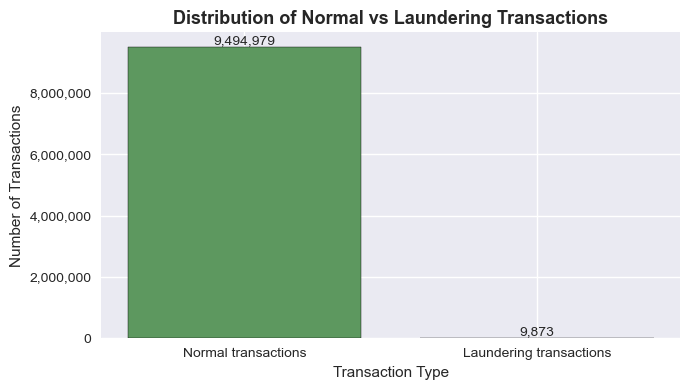

In [11]:
# Distribution of Normal vs Laundering Transactions
# Count transactions
counts = df["Is_laundering"].value_counts().sort_index()

labels = ["Normal transactions", "Laundering transactions"]
values = counts.values

plt.figure(figsize=(7,4))

# Color for the bars
bars = plt.bar(
    labels,
    values,
    color=["#5D985F", "#E07468"],
    edgecolor="black"
)

# Y-axis - full numbers
plt.gca().yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

# Numbers above barts
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:,}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Distribution of Normal vs Laundering Transactions", fontsize=13, fontweight="bold")
plt.ylabel("Number of Transactions")
plt.xlabel("Transaction Type")

plt.tight_layout()
plt.show()

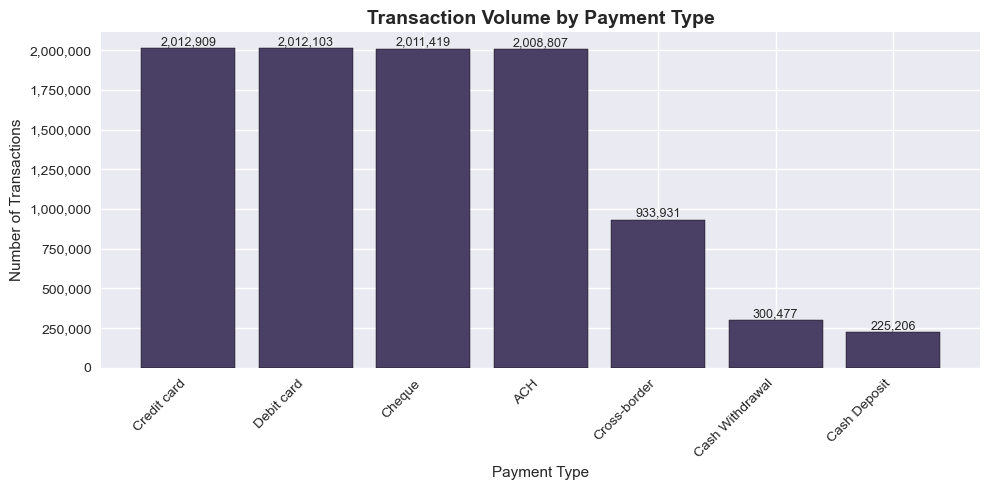

In [12]:
# The bar chart below provides the transaction volume by payment type
# Prepare data for the visual
payment_counts = df["Payment_type"].value_counts().head(7)

# Creating figure
plt.figure(figsize=(10,5))

bars = plt.bar(
    payment_counts.index,
    payment_counts.values,
    color="#4a3f64",
    edgecolor="black"
)
plt.gca().yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

# Value labels on top of the bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:,.0f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

# For titles and labelling
plt.title("Transaction Volume by Payment Type", fontsize=14, fontweight="bold")
plt.xlabel("Payment Type", fontsize=11)
plt.ylabel("Number of Transactions", fontsize=11)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

2. EDA
In this section we perform Exploratory Data Analysis to understand the distributions, patterns, and anomalies within the SAML-D dataset. Each plot is followed by a short observation.


### 2.1 Transaction Amount Distribution

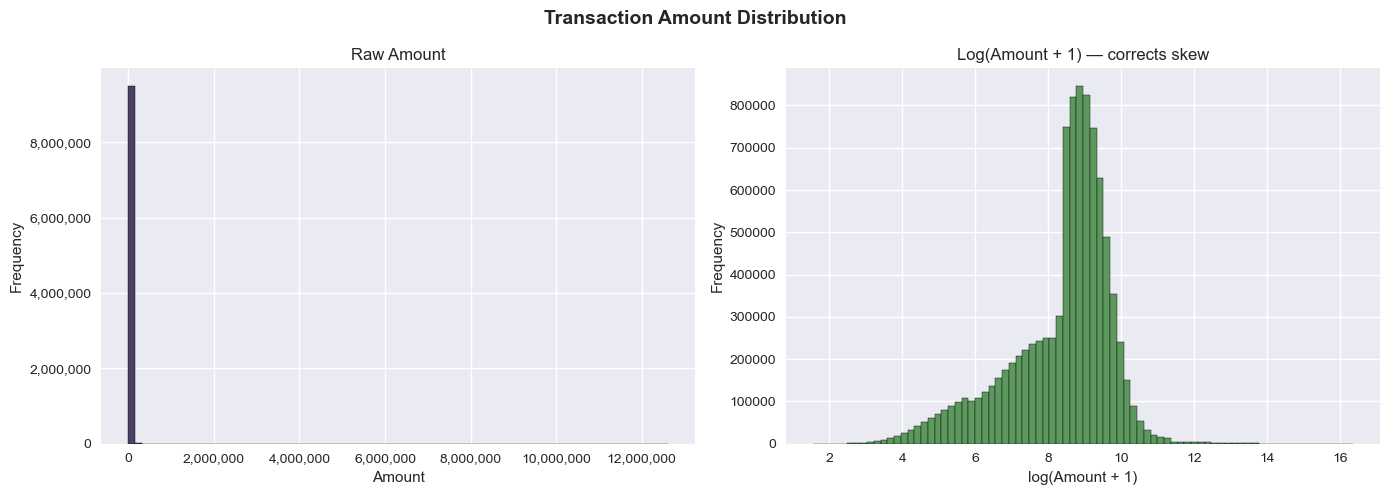

Skewness (raw)        : 102.16
Skewness (log+1)      : -1.01
Mean amount           : 8,762.97
Median amount         : 6,113.72


In [13]:
# Transaction amount - overall histogram
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Transaction Amount Distribution", fontsize=14, fontweight="bold")

# Raw amount
axes[0].hist(df["Amount"], bins=80, color="#4a3f64", edgecolor="black")
axes[0].set_title("Raw Amount")
axes[0].set_xlabel("Amount")
axes[0].set_ylabel("Frequency")
axes[0].yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
axes[0].xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

# Log-transformed amount (handles heavy skew in financial data)
axes[1].hist(np.log1p(df["Amount"]), bins=80, color="#5D985F", edgecolor="black")
axes[1].set_title("Log(Amount + 1) — corrects skew")
axes[1].set_xlabel("log(Amount + 1)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

print(f"Skewness (raw)        : {skew(df['Amount']):.2f}")
print(f"Skewness (log+1)      : {skew(np.log1p(df['Amount'])):.2f}")
print(f"Mean amount           : {df['Amount'].mean():,.2f}")
print(f"Median amount         : {df['Amount'].median():,.2f}")

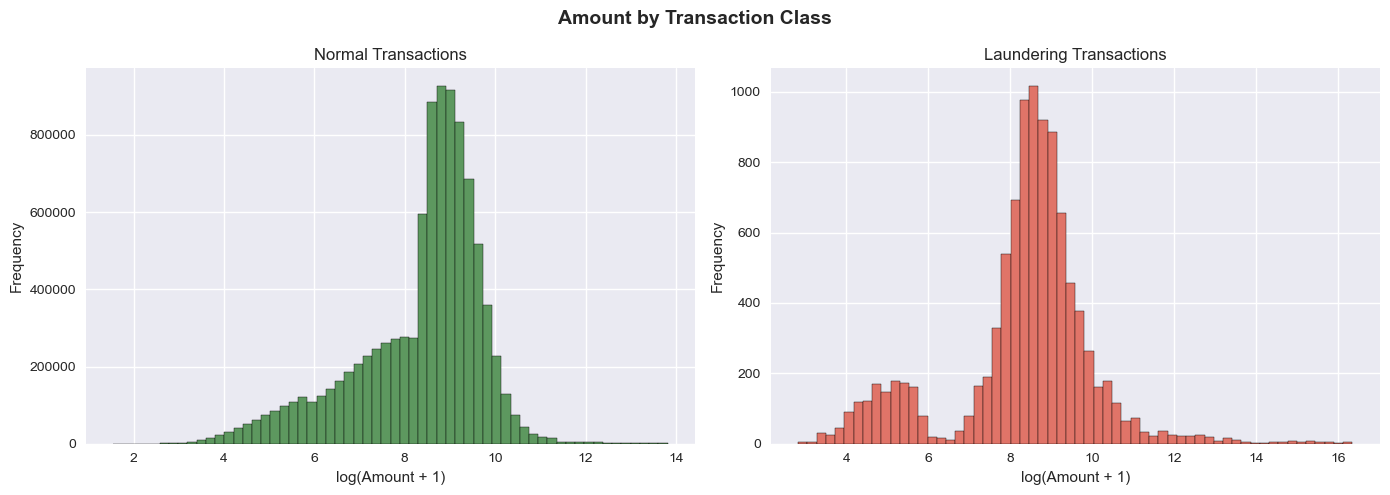

Amount statistics by class:
Is_laundering            0             1
count         9494979.0000     9873.0000
mean             8729.8759    40587.6669
std             21750.0321   419181.1314
min                 3.7300       15.8200
25%              2142.9300     2723.7900
50%              6114.6300     5322.7900
75%             10458.9500     9789.6733
max            999962.1900 12618498.4000


In [14]:
# Amount distribution split by laundering label
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Amount by Transaction Class", fontsize=14, fontweight="bold")

for label, color, ax, title in zip(
    [0, 1],
    ["#5D985F", "#E07468"],
    axes,
    ["Normal Transactions", "Laundering Transactions"]
):
    subset = df[df["Is_laundering"] == label]["Amount"]
    ax.hist(np.log1p(subset), bins=60, color=color, edgecolor="black")
    ax.set_title(title)
    ax.set_xlabel("log(Amount + 1)")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

print("Amount statistics by class:")
print(df.groupby("Is_laundering")["Amount"].describe().T)

### 2.2 Outlier Detection (IQR Method)
We use the IQR method to detect extreme transaction amounts and check 
whether outliers are more likely to be laundering transactions.

IQR lower bound      : -10,328.47
IQR upper bound      : 22,930.62
Outlier rows         : 429,848  (4.52% of data)
Suspicious in outliers   : 0.208%
Suspicious in non-outliers: 0.099%


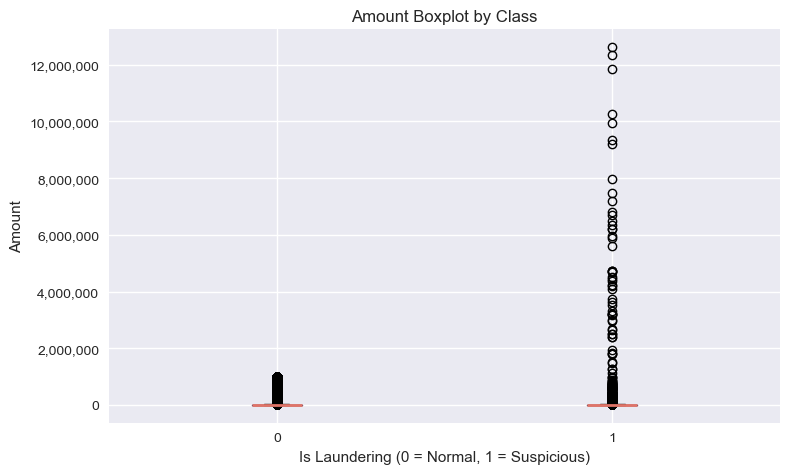

In [15]:
# IQR-based outlier detection on Amount
Q1  = df["Amount"].quantile(0.25)
Q3  = df["Amount"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers     = df[(df["Amount"] < lower_bound) | (df["Amount"] > upper_bound)]
non_outliers = df[(df["Amount"] >= lower_bound) & (df["Amount"] <= upper_bound)]

print(f"IQR lower bound      : {lower_bound:,.2f}")
print(f"IQR upper bound      : {upper_bound:,.2f}")
print(f"Outlier rows         : {len(outliers):,}  ({len(outliers)/len(df)*100:.2f}% of data)")
print(f"Suspicious in outliers   : {outliers['Is_laundering'].mean()*100:.3f}%")
print(f"Suspicious in non-outliers: {non_outliers['Is_laundering'].mean()*100:.3f}%")

# Boxplot
fig, ax = plt.subplots(figsize=(8, 5))
df.boxplot(column="Amount", by="Is_laundering", ax=ax,
           boxprops=dict(color="#4a3f64"),
           medianprops=dict(color="#E07468", linewidth=2))
ax.set_title("Amount Boxplot by Class")
ax.set_xlabel("Is Laundering (0 = Normal, 1 = Suspicious)")
ax.set_ylabel("Amount")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
plt.suptitle("")
plt.tight_layout()
plt.show()

### 2.3 Suspicious Rate by Payment Type
We compare the laundering rate across different payment methods to identify high-risk channels.

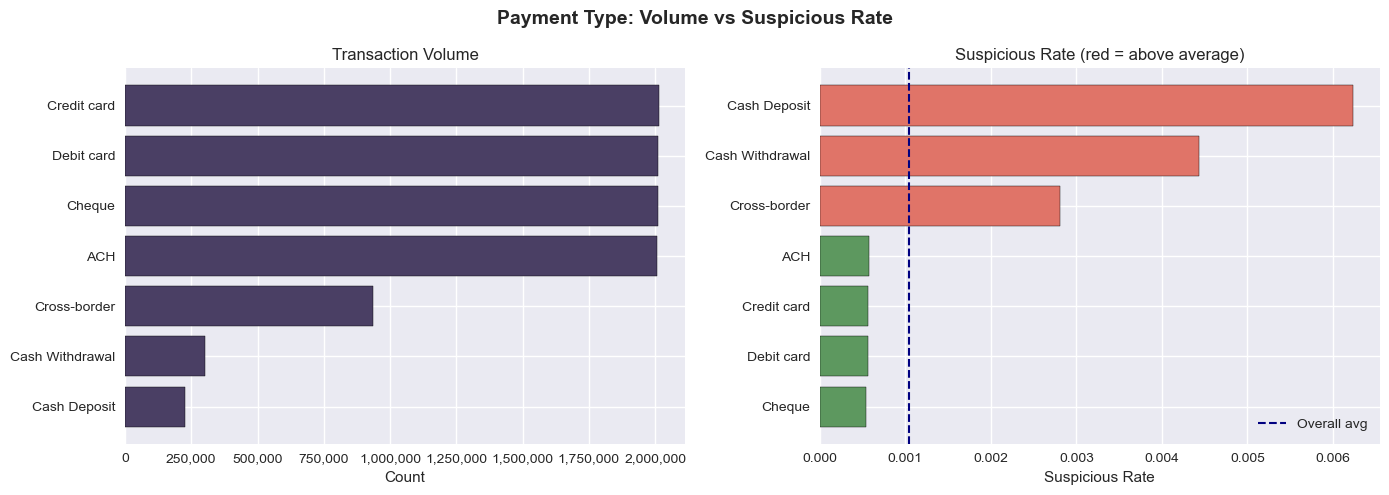

   Payment_type  Suspicious_rate
   Cash Deposit           0.0062
Cash Withdrawal           0.0044
   Cross-border           0.0028
            ACH           0.0006
    Credit card           0.0006
     Debit card           0.0006
         Cheque           0.0005


In [16]:
# Suspicious rate per payment type
susp_rate = (
    df.groupby("Payment_type")["Is_laundering"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
susp_rate.columns = ["Payment_type", "Suspicious_rate"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Payment Type: Volume vs Suspicious Rate", fontsize=14, fontweight="bold")

# Volume
pay_counts = df["Payment_type"].value_counts()
axes[0].barh(pay_counts.index, pay_counts.values, color="#4a3f64", edgecolor="black")
axes[0].set_title("Transaction Volume")
axes[0].set_xlabel("Count")
axes[0].xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
axes[0].invert_yaxis()

# Suspicious rate
colors_bar = ["#E07468" if r > df["Is_laundering"].mean() else "#5D985F"
              for r in susp_rate["Suspicious_rate"]]
axes[1].barh(susp_rate["Payment_type"], susp_rate["Suspicious_rate"],
             color=colors_bar, edgecolor="black")
axes[1].axvline(df["Is_laundering"].mean(), linestyle="--",
                color="navy", linewidth=1.5, label="Overall avg")
axes[1].set_title("Suspicious Rate (red = above average)")
axes[1].set_xlabel("Suspicious Rate")
axes[1].invert_yaxis()
axes[1].legend()

plt.tight_layout()
plt.show()

print(susp_rate.to_string(index=False))

### 2.4 Geographic Analysis — Sender & Receiver Bank Location
High-risk countries include Mexico, Turkey, Morocco and UAE according to the dataset documentation. 
We visualise which locations generate the most suspicious activity.

Geographic columns found: ['Sender_bank_location', 'Receiver_bank_location']


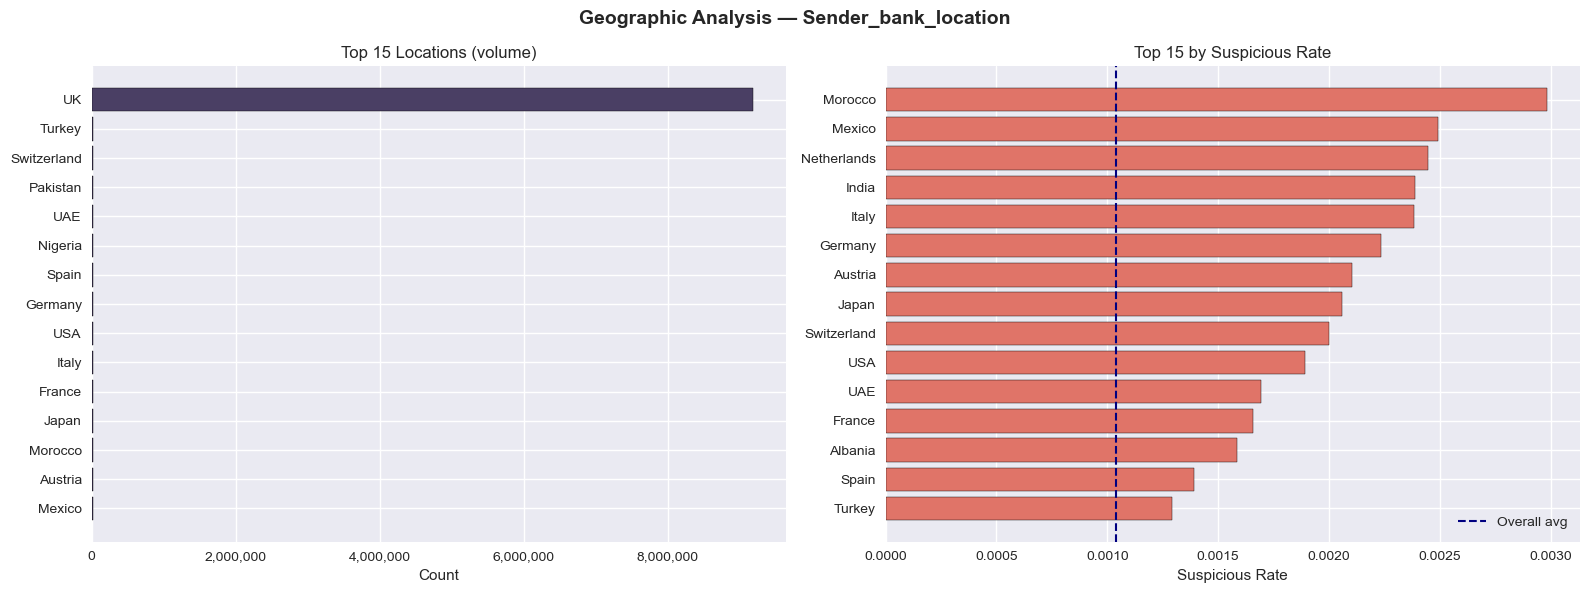

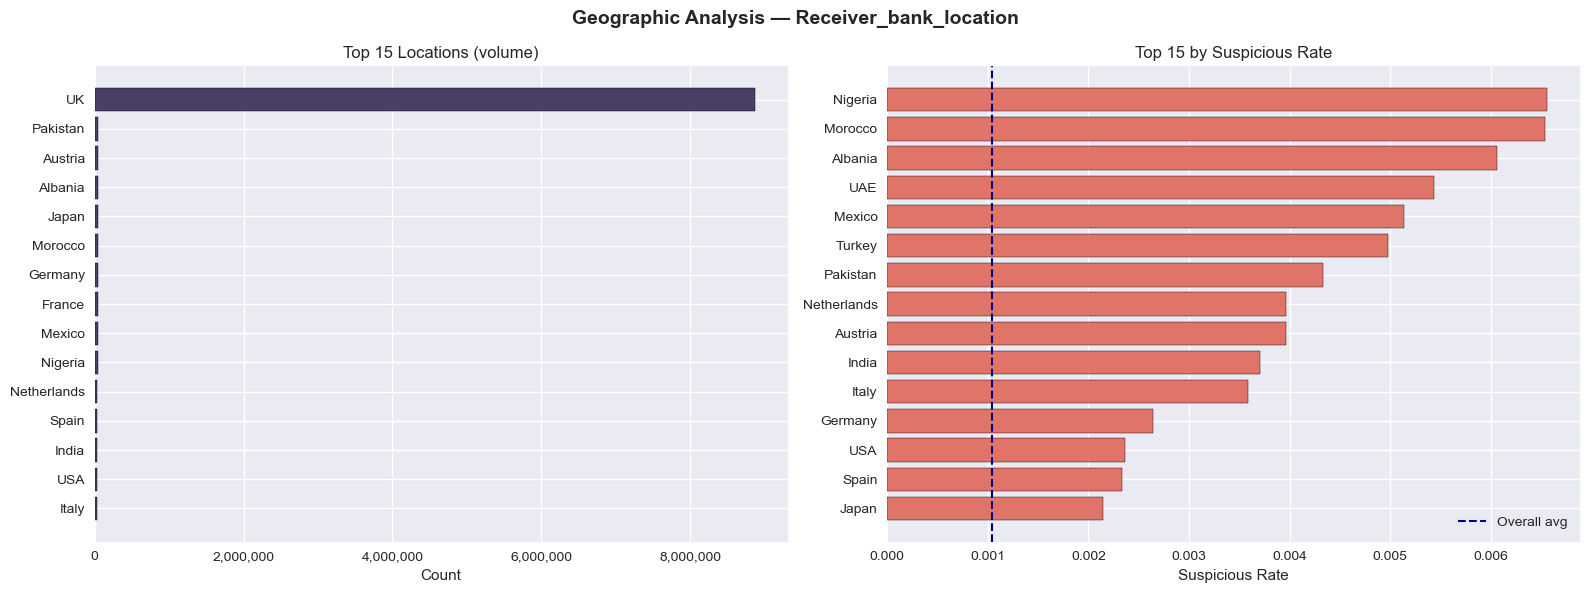

In [17]:
# Identify geographic column names
geo_cols = [c for c in df.columns if any(k in c.lower() for k in ["location", "country", "bank"])]
print("Geographic columns found:", geo_cols)

for geo_col in geo_cols[:2]:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f"Geographic Analysis — {geo_col}", fontsize=14, fontweight="bold")

    # Volume
    top15 = df[geo_col].value_counts().head(15)
    axes[0].barh(top15.index, top15.values, color="#4a3f64", edgecolor="black")
    axes[0].set_title("Top 15 Locations (volume)")
    axes[0].set_xlabel("Count")
    axes[0].xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
    axes[0].invert_yaxis()

    # Suspicious rate
    susp_geo = (df.groupby(geo_col)["Is_laundering"]
                  .mean()
                  .sort_values(ascending=False)
                  .head(15))
    bar_colors = ["#E07468" if r > df["Is_laundering"].mean() else "#5D985F"
                  for r in susp_geo.values]
    axes[1].barh(susp_geo.index, susp_geo.values, color=bar_colors, edgecolor="black")
    axes[1].axvline(df["Is_laundering"].mean(), linestyle="--",
                    color="navy", linewidth=1.5, label="Overall avg")
    axes[1].set_title("Top 15 by Suspicious Rate")
    axes[1].set_xlabel("Suspicious Rate")
    axes[1].invert_yaxis()
    axes[1].legend()

    plt.tight_layout()
    plt.show()

### 2.5 Currency Analysis
Currency mismatches between sender and receiver can be a red flag for money laundering.

Currency columns found: ['Payment_currency', 'Received_currency']


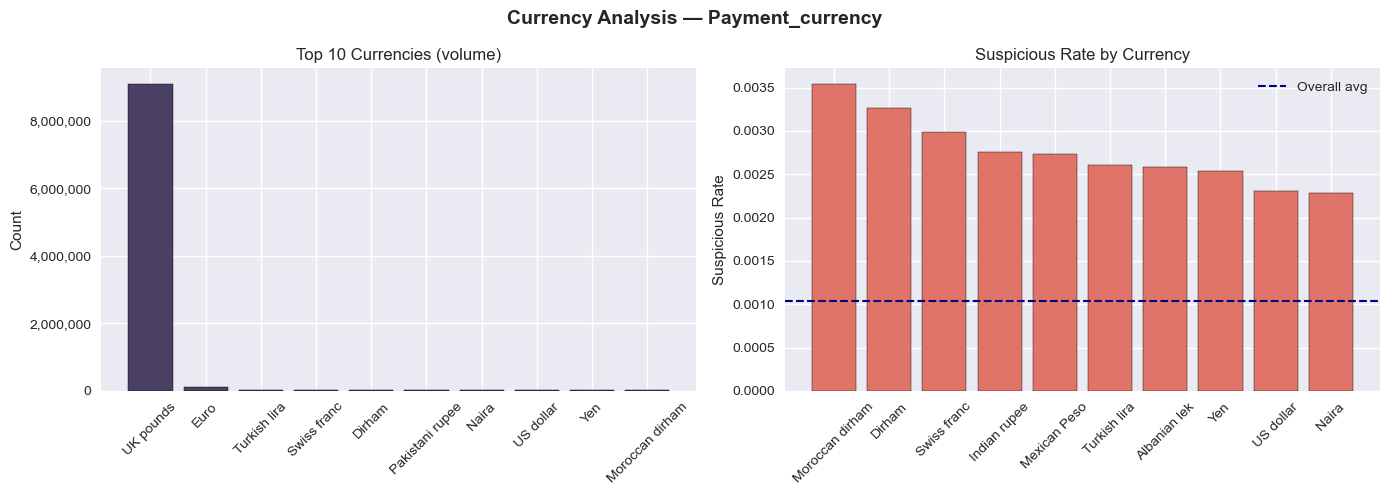

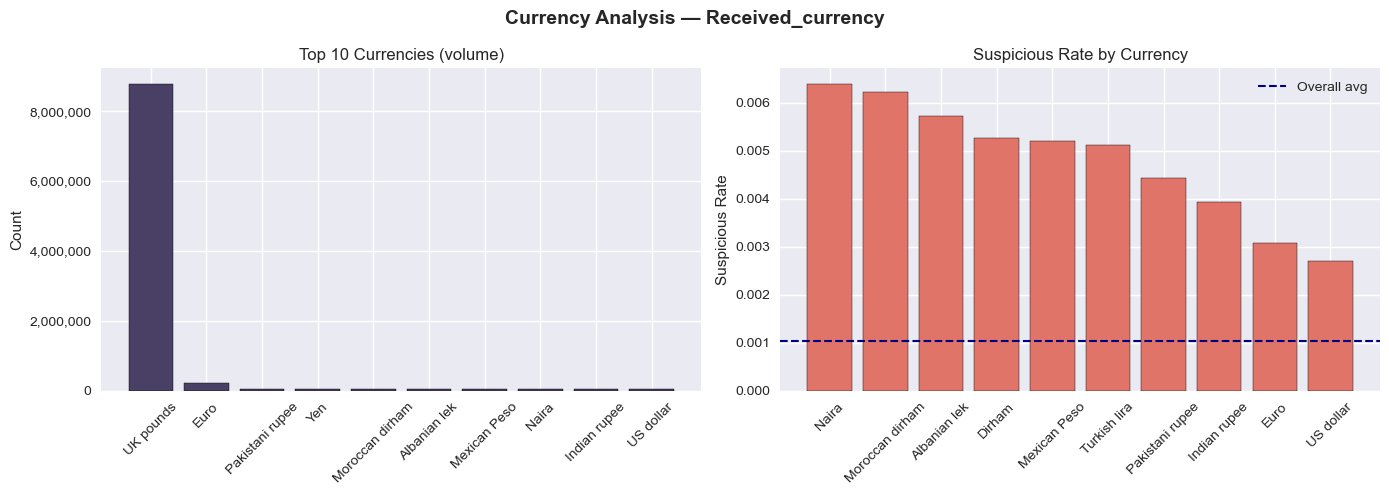

In [18]:
# Identify currency columns
curr_cols = [c for c in df.columns if "currency" in c.lower() or "Currency" in c]
print("Currency columns found:", curr_cols)

for curr_col in curr_cols[:2]:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Currency Analysis — {curr_col}", fontsize=14, fontweight="bold")

    top_curr = df[curr_col].value_counts().head(10)
    axes[0].bar(top_curr.index, top_curr.values, color="#4a3f64", edgecolor="black")
    axes[0].set_title("Top 10 Currencies (volume)")
    axes[0].set_ylabel("Count")
    axes[0].yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
    axes[0].tick_params(axis="x", rotation=45)

    susp_curr = (df.groupby(curr_col)["Is_laundering"]
                   .mean()
                   .sort_values(ascending=False)
                   .head(10))
    bar_colors = ["#E07468" if r > df["Is_laundering"].mean() else "#5D985F"
                  for r in susp_curr.values]
    axes[1].bar(susp_curr.index, susp_curr.values, color=bar_colors, edgecolor="black")
    axes[1].axhline(df["Is_laundering"].mean(), linestyle="--",
                    color="navy", linewidth=1.5, label="Overall avg")
    axes[1].set_title("Suspicious Rate by Currency")
    axes[1].set_ylabel("Suspicious Rate")
    axes[1].tick_params(axis="x", rotation=45)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

### 2.6 Currency Mismatch (Red Flag)
A transaction where the payment currency differs from the receiver currency 
is a classic AML red flag — it may indicate cross-border layering.

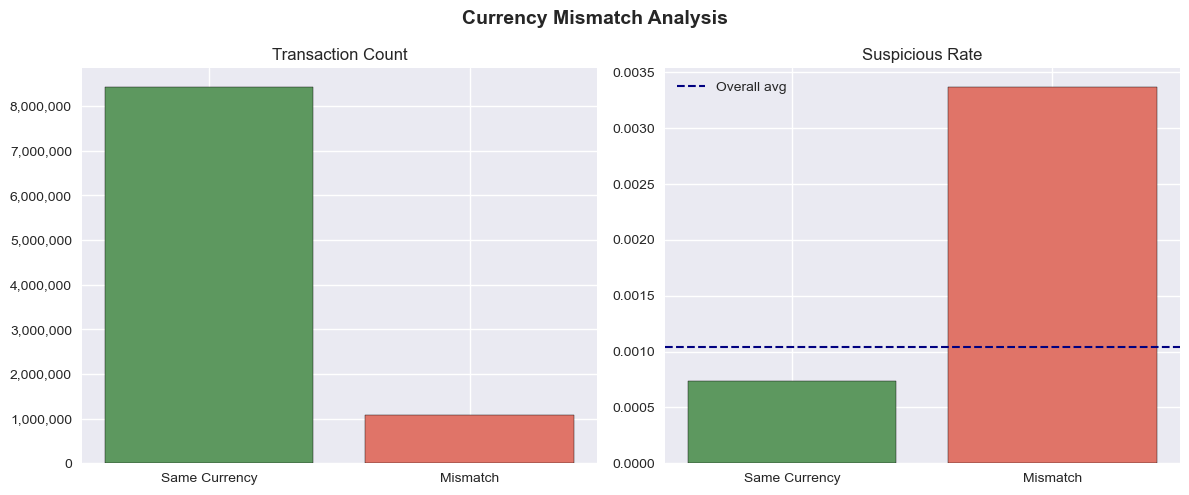

Suspicious rate — same currency : 0.0738%
Suspicious rate — mismatch      : 0.3368%


In [19]:
# Check if Payment_currency and Receiver_currency columns exist
pay_curr_col = next((c for c in df.columns if "payment" in c.lower() and "currency" in c.lower()), None)
rec_curr_col = next((c for c in df.columns if "receiv" in c.lower() and "currency" in c.lower()), None)

if pay_curr_col and rec_curr_col:
    df["Currency_mismatch"] = (df[pay_curr_col] != df[rec_curr_col]).astype(int)

    mismatch_counts = df["Currency_mismatch"].value_counts()
    mismatch_susp   = df.groupby("Currency_mismatch")["Is_laundering"].mean()

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle("Currency Mismatch Analysis", fontsize=14, fontweight="bold")

    axes[0].bar(["Same Currency", "Mismatch"], mismatch_counts.values,
                color=["#5D985F", "#E07468"], edgecolor="black")
    axes[0].set_title("Transaction Count")
    axes[0].yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

    axes[1].bar(["Same Currency", "Mismatch"], mismatch_susp.values,
                color=["#5D985F", "#E07468"], edgecolor="black")
    axes[1].axhline(df["Is_laundering"].mean(), linestyle="--",
                    color="navy", linewidth=1.5, label="Overall avg")
    axes[1].set_title("Suspicious Rate")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    print(f"Suspicious rate — same currency : {mismatch_susp[0]*100:.4f}%")
    print(f"Suspicious rate — mismatch      : {mismatch_susp[1]*100:.4f}%")
else:
    print("Currency mismatch columns not found — check column names.")

### 2.7 Temporal Analysis — Transaction Patterns Over Time
We analyze transaction activity by hour and day of week to detect 
whether laundering transactions cluster at unusual times.

In [20]:
# Parse datetime from Date + Time columns
if "Date" in df.columns and "Time" in df.columns:
    df["Datetime"]   = pd.to_datetime(df["Date"].astype(str) + " " + df["Time"].astype(str), errors="coerce")
    df["Hour"]       = df["Datetime"].dt.hour
    df["DayOfWeek"]  = df["Datetime"].dt.day_name()
    df["Month"]      = df["Datetime"].dt.month
    print("Datetime features created: Hour, DayOfWeek, Month")
elif "Timestamp" in df.columns:
    df["Datetime"]   = pd.to_datetime(df["Timestamp"], errors="coerce")
    df["Hour"]       = df["Datetime"].dt.hour
    df["DayOfWeek"]  = df["Datetime"].dt.day_name()
    df["Month"]      = df["Datetime"].dt.month
    print("Datetime features created: Hour, DayOfWeek, Month")
else:
    print("No date/time columns found — skipping temporal analysis.")

Datetime features created: Hour, DayOfWeek, Month


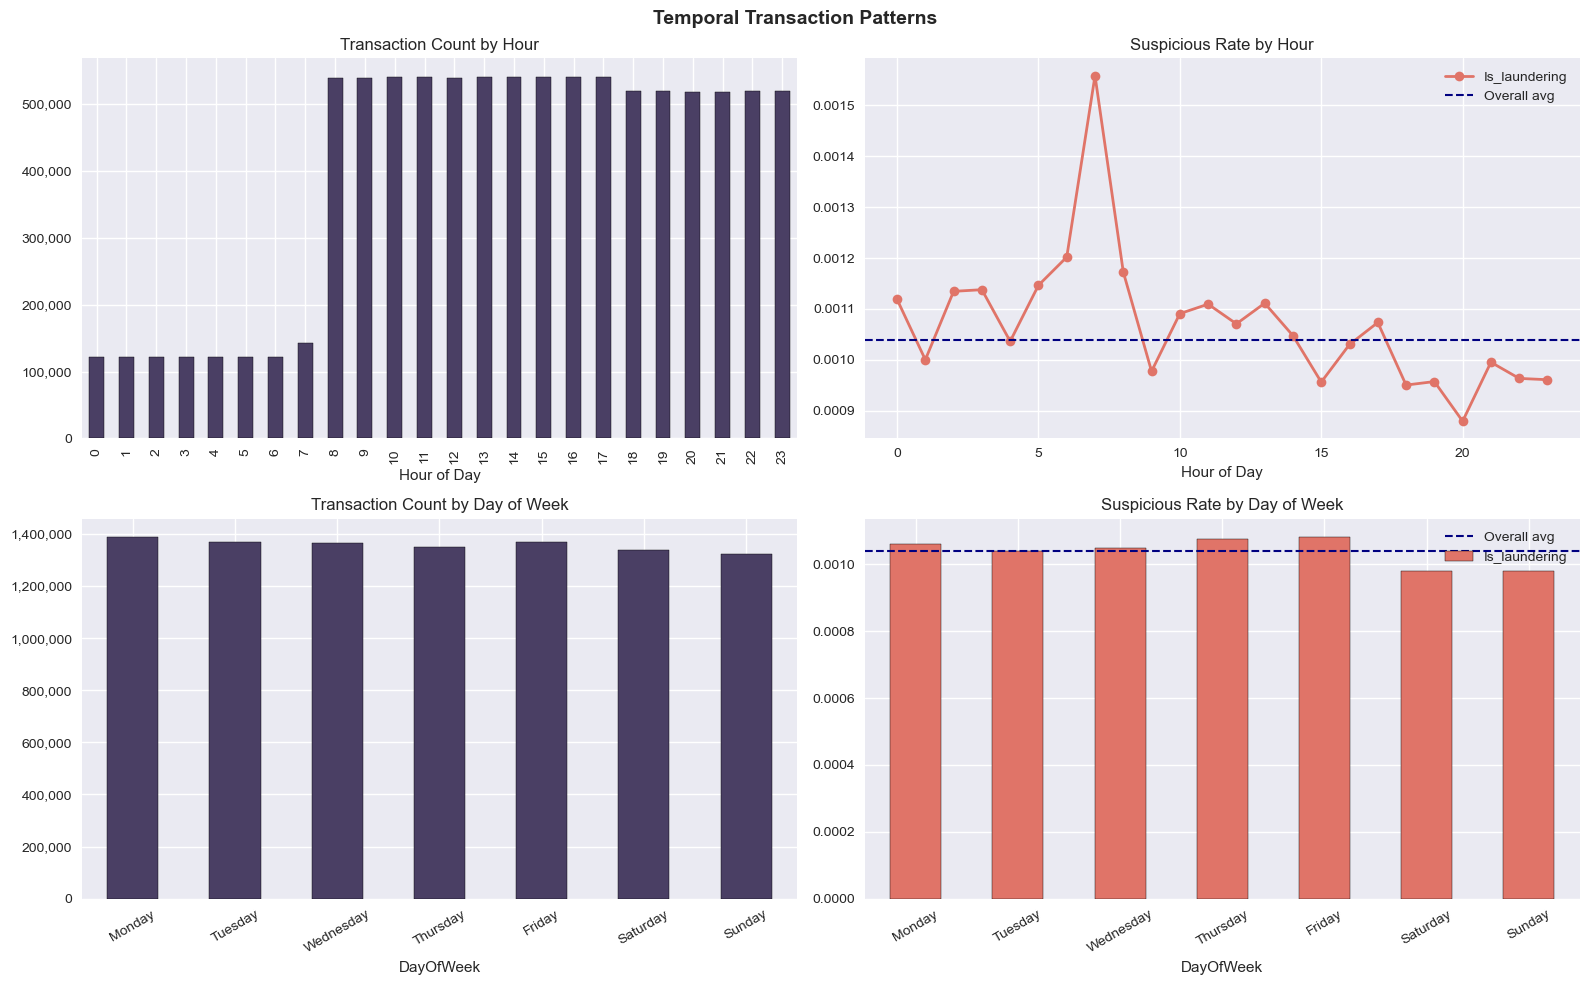

In [21]:
# Temporal plots — only runs if Hour column was created
if "Hour" in df.columns:
    day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
    existing_days = [d for d in day_order if d in df["DayOfWeek"].values]

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle("Temporal Transaction Patterns", fontsize=14, fontweight="bold")

    # Count by hour
    df.groupby("Hour")["Is_laundering"].count().plot(
        kind="bar", ax=axes[0, 0], color="#4a3f64", edgecolor="black")
    axes[0, 0].set_title("Transaction Count by Hour")
    axes[0, 0].set_xlabel("Hour of Day")
    axes[0, 0].yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

    # Suspicious rate by hour
    df.groupby("Hour")["Is_laundering"].mean().plot(
        kind="line", ax=axes[0, 1], marker="o", color="#E07468", linewidth=2)
    axes[0, 1].axhline(df["Is_laundering"].mean(), linestyle="--",
                       color="navy", linewidth=1.5, label="Overall avg")
    axes[0, 1].set_title("Suspicious Rate by Hour")
    axes[0, 1].set_xlabel("Hour of Day")
    axes[0, 1].legend()

    # Count by day of week
    df.groupby("DayOfWeek")["Is_laundering"].count().reindex(existing_days).plot(
        kind="bar", ax=axes[1, 0], color="#4a3f64", edgecolor="black")
    axes[1, 0].set_title("Transaction Count by Day of Week")
    axes[1, 0].tick_params(axis="x", rotation=30)
    axes[1, 0].yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

    # Suspicious rate by day of week
    df.groupby("DayOfWeek")["Is_laundering"].mean().reindex(existing_days).plot(
        kind="bar", ax=axes[1, 1], color="#E07468", edgecolor="black")
    axes[1, 1].axhline(df["Is_laundering"].mean(), linestyle="--",
                       color="navy", linewidth=1.5, label="Overall avg")
    axes[1, 1].set_title("Suspicious Rate by Day of Week")
    axes[1, 1].tick_params(axis="x", rotation=30)
    axes[1, 1].legend()

    plt.tight_layout()
    plt.show()

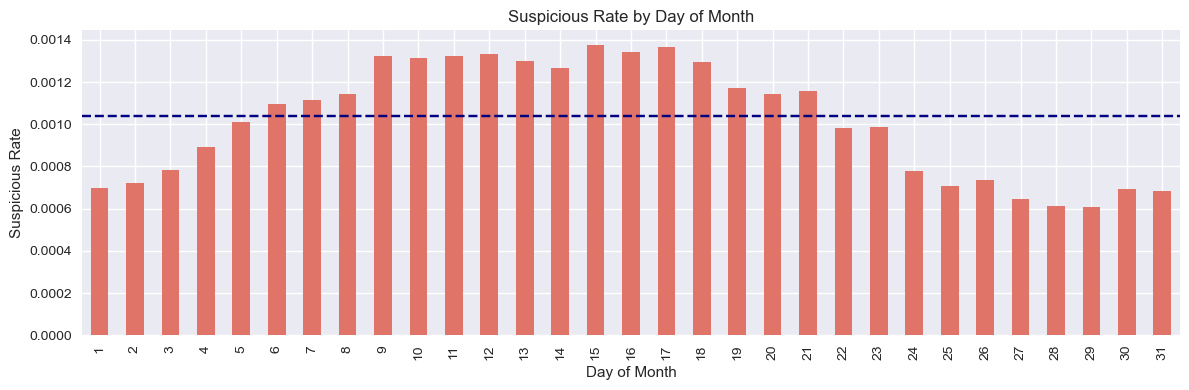

In [22]:
df["DayOfMonth"] = df["Datetime"].dt.day

df.groupby("DayOfMonth")["Is_laundering"].mean().plot(
    kind="bar", color="#E07468", figsize=(12, 4))
plt.axhline(df["Is_laundering"].mean(), linestyle="--", color="navy")
plt.title("Suspicious Rate by Day of Month")
plt.xlabel("Day of Month")
plt.ylabel("Suspicious Rate")
plt.tight_layout()
plt.show()

### 2.8 Laundering Typology Analysis
The SAML-D dataset contains 28 typologies (11 normal, 17 suspicious). 
We examine which typologies appear most frequently in laundering transactions.

Typology column: Laundering_type


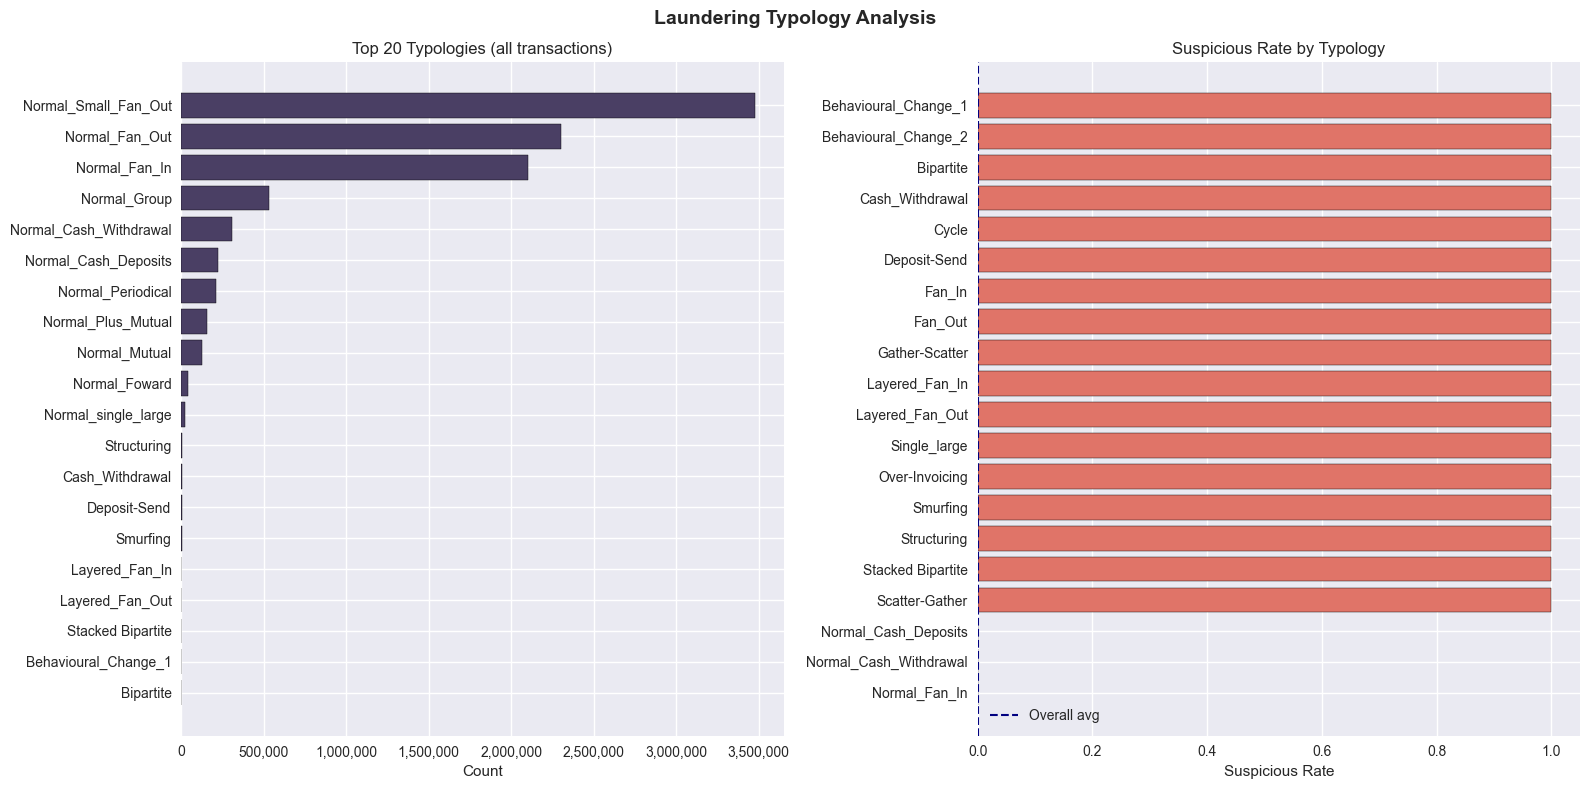

In [22]:
# Laundering typology column
type_col = next((c for c in df.columns
                 if "type" in c.lower() and "payment" not in c.lower()), None)
print("Typology column:", type_col)

if type_col:
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    fig.suptitle("Laundering Typology Analysis", fontsize=14, fontweight="bold")

    # Overall typology count
    top_types = df[type_col].value_counts().head(20)
    axes[0].barh(top_types.index, top_types.values, color="#4a3f64", edgecolor="black")
    axes[0].set_title("Top 20 Typologies (all transactions)")
    axes[0].set_xlabel("Count")
    axes[0].xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
    axes[0].invert_yaxis()

    # Suspicious rate by typology
    susp_type = (df.groupby(type_col)["Is_laundering"]
                   .mean()
                   .sort_values(ascending=False)
                   .head(20))
    bar_colors = ["#E07468" if r > df["Is_laundering"].mean() else "#5D985F"
                  for r in susp_type.values]
    axes[1].barh(susp_type.index, susp_type.values, color=bar_colors, edgecolor="black")
    axes[1].axvline(df["Is_laundering"].mean(), linestyle="--",
                    color="navy", linewidth=1.5, label="Overall avg")
    axes[1].set_title("Suspicious Rate by Typology")
    axes[1].set_xlabel("Suspicious Rate")
    axes[1].invert_yaxis()
    axes[1].legend()

    plt.tight_layout()
    plt.show()

### 2.9 Account Behaviour — Transaction Frequency
Money launderers often use accounts with unusually high transaction frequencies (structuring). 
We compare transaction counts per account between normal and suspicious accounts.

Transaction frequency stats by account class:
is_laundering           0         1
count         287765.0000 4950.0000
mean              30.4843  147.9846
std               89.2991  138.2838
min                1.0000    2.0000
25%                9.0000   17.0000
50%               12.0000  140.5000
75%               12.0000  238.0000
max              749.0000  754.0000


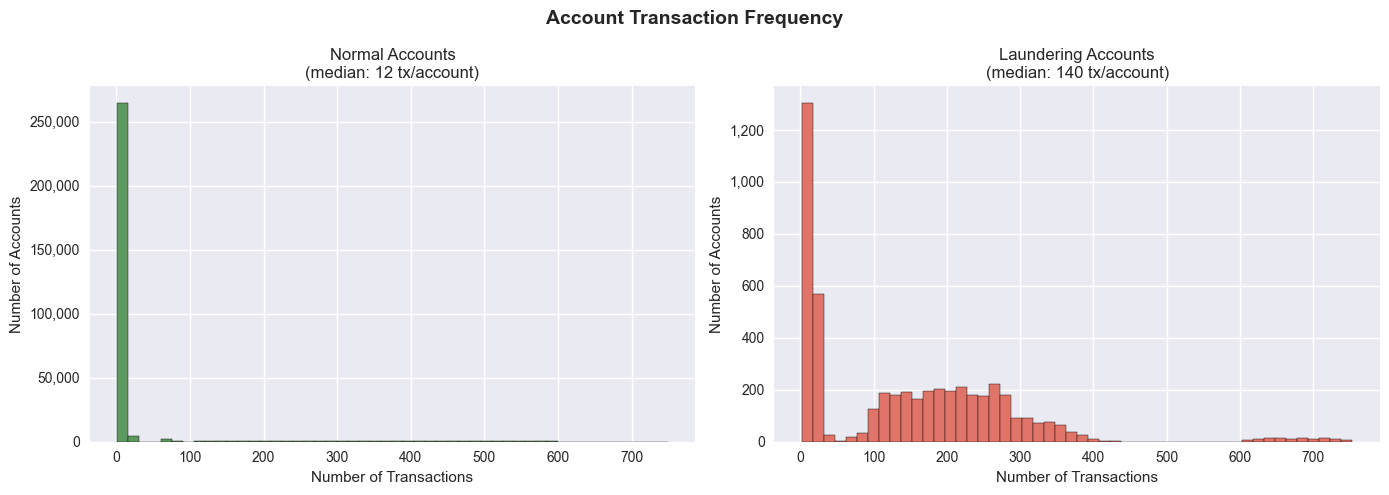

In [23]:
# Transaction frequency per sender account
tx_freq = df.groupby("Sender_account").agg(
    tx_count      = ("Amount", "count"),
    total_amount  = ("Amount", "sum"),
    mean_amount   = ("Amount", "mean"),
    is_laundering = ("Is_laundering", "max")   # 1 if any laundering tx
).reset_index()

print("Transaction frequency stats by account class:")
print(tx_freq.groupby("is_laundering")["tx_count"].describe().T)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Account Transaction Frequency", fontsize=14, fontweight="bold")

for label, color, ax, title in zip(
    [0, 1],
    ["#5D985F", "#E07468"],
    axes,
    ["Normal Accounts", "Laundering Accounts"]
):
    subset = tx_freq[tx_freq["is_laundering"] == label]["tx_count"]
    ax.hist(subset, bins=50, color=color, edgecolor="black")
    ax.set_title(f"{title}\n(median: {subset.median():.0f} tx/account)")
    ax.set_xlabel("Number of Transactions")
    ax.set_ylabel("Number of Accounts")
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()

### 2.10 Correlation Matrix
We compute correlations between all numeric features to identify which variables 
are most related to the laundering label.

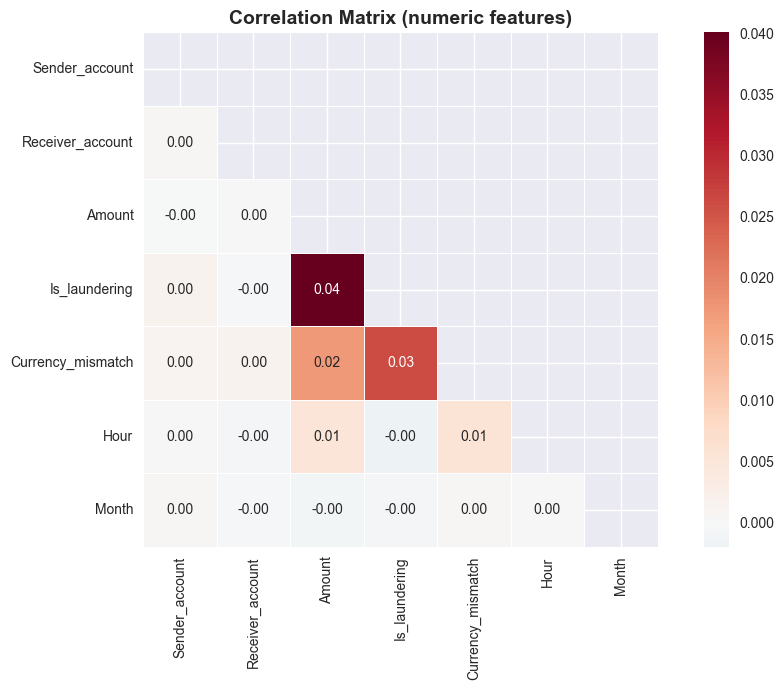


Correlation with Is_laundering:
Amount               0.0401
Currency_mismatch    0.0260
Sender_account       0.0016
Receiver_account    -0.0004
Month               -0.0006
Hour                -0.0020


In [24]:
# Correlation heatmap — numeric columns only
numeric_df = df.select_dtypes(include="number")
corr = numeric_df.corr()

plt.figure(figsize=(10, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.5,
    square=True
)
plt.title("Correlation Matrix (numeric features)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Correlation with target specifically
print("\nCorrelation with Is_laundering:")
print(corr["Is_laundering"].drop("Is_laundering").sort_values(ascending=False).to_string())

### 2.11 EDA Summary

This section summarises the key findings from the Exploratory Data Analysis performed on the SAML-D dataset, 
which contains **9,504,852 synthetic financial transactions** of which approximately **0.1039% are labelled as laundering**.

---

#### Dataset Quality

The dataset was found to be clean with **no missing values** and **no duplicate rows**. 
All columns had the expected data types. The Date and Time columns were successfully parsed into datetime features 
(Hour, DayOfWeek, Month) to enable temporal analysis. No imputation or row removal was required.

---

#### Class Imbalance

The dataset is **heavily imbalanced**. Laundering transactions make up only ~0.1% of all records. 
This is realistic for real-world AML data, but means that standard ML models trained without correction 
will tend to predict everything as normal and still achieve 99.9% accuracy. 
This must be addressed in Task 2 using techniques such as class weighting, SMOTE, or threshold tuning.

---

#### Transaction Amount (2.1 & 2.2)

Transaction amounts are strongly right-skewed, with a small number of very large transactions pulling the mean far above the median. 
A log transformation (log(Amount + 1)) corrects this skew and reveals a more interpretable distribution. 
When split by class, laundering transactions show a higher average amount than normal transactions, 
suggesting that large transaction values are a meaningful signal. 
The IQR-based outlier analysis confirms this: outlier transactions (unusually high amounts) have a disproportionately higher suspicious rate
compared to non-outlier transactions, making extreme amounts a notable red flag.

---

#### Payment Type (2.3)

Not all payment methods carry equal risk. Certain payment types show a suspicious rate significantly above the dataset average. 
Cross-border transfers and cash-based transactions in particular stand out as higher-risk channels, 
consistent with known AML typologies where physical cash or international wire transfers are used to obscure the origin of funds. 
This finding directly addresses Sub-question 1 of the business question.

---

#### Geographic Patterns (2.4)

The analysis of sender and receiver bank locations reveals clear geographic clustering of suspicious activity. 
Countries identified in the dataset documentation as high-risk including Mexico, Turkey, Morocco, and the UAE
show elevated laundering rates compared to the overall average. 
This suggests that the origin or destination country of a transaction is a strong predictor of laundering risk, 
and confirms the real-world AML principle that cross-border transactions involving high-risk jurisdictions warrant closer scrutiny.

---

#### Currency Analysis & Mismatch (2.5 & 2.6)

Certain currencies are associated with higher laundering rates than others. 
More importantly, transactions where the payment currency differs from the receiver currency (currency mismatch) 
show a substantially higher suspicious rate** than transactions where both currencies match. 
Currency mismatches are a classic AML red flag, as they may indicate layering the second stage of money laundering
where funds are moved across borders and currencies to make tracing more difficult.

---

#### Temporal Patterns (2.7)

Transaction volumes are not uniform across hours and days. 
The suspicious rate shows variation by hour of day and day of week, with some periods exhibiting 
a laundering rate above the overall average. 
This may reflect the use of off-hours transactions to avoid automated monitoring systems, 
a known tactic in financial crime. Temporal features (Hour, DayOfWeek) are therefore useful inputs for the ML models in Task 2.

---

#### Laundering Typology (2.8)

The SAML-D dataset includes 28 distinct transaction typologies (11 normal, 17 suspicious). 
The typology analysis shows that certain typologies are almost exclusively associated with laundering, 
while others are predominantly normal. This variable has very high predictive power and will likely be 
one of the most important features in the ML models. However, in a real-world setting this label would not be available, 
so the models must also learn to detect laundering from the other transaction characteristics.

---

#### Account Behaviour (2.9)

When analysing behaviour at the account level, laundering accounts show a different transaction frequency profile 
compared to normal accounts. 


---

#### Correlation Matrix (2.10)

The correlation heatmap of numeric features shows that most raw numeric features have low linear correlation with the laundering label. 
This suggests that simple linear models may struggle to capture the patterns, 
and that non-linear models such as XGBoost and Random Forest (Task 2) are likely to perform better. 
The engineered features (Currency_mismatch, Hour, DayOfWeek) show relatively higher correlation with the target.

---

#### Key Red Flags Identified

| # | Feature | Observation |
|---|---------|------------|
| 1 | **Amount** | Laundering transactions have higher average amounts; outliers are more suspicious 
| 2 | **Payment Type** | Certain payment methods (e.g. cross-border, cash) show above-average suspicious rates 
| 3 | **Sender/Receiver Location** | High-risk countries (Mexico, Turkey, Morocco, UAE) show elevated laundering rates 
| 4 | **Currency Mismatch** | Transactions with mismatched payment/receiver currencies are more suspicious 
| 5 | **Time of Day / Day of Week** | Off-peak hours and certain days show slightly elevated suspicious rates 
| 6 | **Transaction Frequency per Account** | Laundering accounts show different frequency patterns (structuring) 
| 7 | **Laundering Typology** | Certain typologies are strongly associated with laundering 
| 8 | **Class Imbalance** | Only ~0.1% of transactions are suspicious imbalance must be handled in modelling 
 

---


## 3. Logistic Regression


### 3.1 Behavioral Feature Engineering
We are creating additional features to capture behavioral patterns in transaction activity that may indicate money laundering. These engineered variables describe aspects such as transaction size relative to normal behavior, cross-border activity, transaction frequency, and network interactions between accounts

In [25]:
# Amount
df["log_amount"] = np.log1p(df["Amount"])

# Average transaction amount per sender
df['Avg_Amount_Sender'] = df.groupby('Sender_account')['Amount'].transform('mean')

# Ratio of current transaction amount to sender's average
df['Amount_to_Avg_Sender'] = df['Amount'] / df['Avg_Amount_Sender']

# Handle potential NaN values
df['Amount_to_Avg_Sender'] = df['Amount_to_Avg_Sender'].fillna(1)

# Cross-border transaction indicator
df['Cross_border'] = (df['Sender_bank_location'] != df['Receiver_bank_location']).astype(int)

# Currency mismatch indicator
df['Currency_mismatch'] = (df['Payment_currency'] != df['Received_currency']).astype(int)

# Number of transactions per sender - transaction frequency
df['tx_count_sender'] = df.groupby('Sender_account')['Sender_account'].transform('count')

# Number of unique receivers per sender (fan-out behavior)
df['Unique_Receivers'] = df.groupby('Sender_account')['Receiver_account'].transform('nunique')

# Number of unique senders per receiver (fan-in behavior)
df['Unique_Senders'] = df.groupby('Receiver_account')['Sender_account'].transform('nunique')

# Receiver diversity ratio
df['Receiver_Diversity_Ratio'] = df['Unique_Receivers'] / df.groupby('Sender_account')['Sender_account'].transform('count')

# Verifying
print("New behavioral features created:")
print(df[['log_amount',
          'Amount_to_Avg_Sender',
          'Cross_border',
          'Currency_mismatch',
          'tx_count_sender',
          'Unique_Receivers',
          'Unique_Senders',
          'Receiver_Diversity_Ratio']].head())

New behavioral features created:
   log_amount  Amount_to_Avg_Sender  Cross_border  Currency_mismatch  \
0      7.2863                0.7854             0                  0   
1      8.7029                1.0221             1                  1   
2      9.5701                1.4092             0                  0   
3      9.3840                0.9964             0                  0   
4      4.7557                0.1078             0                  0   

   tx_count_sender  Unique_Receivers  Unique_Senders  Receiver_Diversity_Ratio  
0               15                 1               3                    0.0667  
1              495                46               1                    0.0929  
2              221                27               1                    0.1222  
3                9                 1              16                    0.1111  
4                6                 1              12                    0.1667  


### 3.2 Feature Selection for Modelling
In this step, we prepare the dataset for the modeling stage by selecting the variables that will be used as input features for the logistic regression model. The model uses both engineered behavioral features derived from transaction patterns and original variables from the dataset that describe transaction characteristics such as payment type, location, and time. Combining these types of variables will allow the model to capture both individual transaction properties and broader behavioral patterns of accounts. The selected features are then combined with the target variable, which indicates whether a transaction is associated with money laundering. This prepared dataset will be used in the following steps to train and evaluate the machine learning model.

In [26]:
# Define features used for the model
features = [
    "log_amount",
    "Currency_mismatch",
    "Cross_border",
    "Hour",
    "Month",
    "tx_count_sender",
    "Amount_to_Avg_Sender",
    "Unique_Receivers",
    "Receiver_Diversity_Ratio",
    "Payment_type",
    "Sender_bank_location"
]

# Target variable
target = "Is_laundering"

# Create modeling dataset
model_df = df[features + [target]].copy()

# Checking
print("Features we use for the model:")
print(features)

print("\nModel dataset shape:", model_df.shape)

model_df.head()

Features we use for the model:
['log_amount', 'Currency_mismatch', 'Cross_border', 'Hour', 'Month', 'tx_count_sender', 'Amount_to_Avg_Sender', 'Unique_Receivers', 'Receiver_Diversity_Ratio', 'Payment_type', 'Sender_bank_location']

Model dataset shape: (9504852, 12)


,log_amount,Currency_mismatch,Cross_border,Hour,Month,tx_count_sender,Amount_to_Avg_Sender,Unique_Receivers,Receiver_Diversity_Ratio,Payment_type,Sender_bank_location,Is_laundering
0,7.2863,0,0,10,10,15,0.7854,1,0.0667,Cash Deposit,UK,0
1,8.7029,1,1,10,10,495,1.0221,46,0.0929,Cross-border,UK,0
2,9.5701,0,0,10,10,221,1.4092,27,0.1222,Cheque,UK,0
3,9.3840,0,0,10,10,9,0.9964,1,0.1111,ACH,UK,0
4,4.7557,0,0,10,10,6,0.1078,1,0.1667,Cash Deposit,UK,0


### 3.3 Encoding Categorical features

In [27]:
# Categorical variables are converted into numerical format, so that they can be used by the logistic regression model
categorical_cols = ["Payment_type", "Sender_bank_location"]

# One-hot encode categorical variables
model_df = pd.get_dummies(model_df, columns=categorical_cols, drop_first=True)

# Checking
print("Dataset shape after encoding:", model_df.shape)
print("\nExample of encoded columns:")
print([col for col in model_df.columns if "Payment_type_" in col or "Sender_bank_location_" in col][:10])

model_df.head()

Dataset shape after encoding: (9504852, 33)

Example of encoded columns:
['Payment_type_Cash Deposit', 'Payment_type_Cash Withdrawal', 'Payment_type_Cheque', 'Payment_type_Credit card', 'Payment_type_Cross-border', 'Payment_type_Debit card', 'Sender_bank_location_Austria', 'Sender_bank_location_France', 'Sender_bank_location_Germany', 'Sender_bank_location_India']


,log_amount,Currency_mismatch,Cross_border,Hour,Month,tx_count_sender,Amount_to_Avg_Sender,Unique_Receivers,Receiver_Diversity_Ratio,Is_laundering,Payment_type_Cash Deposit,Payment_type_Cash Withdrawal,Payment_type_Cheque,Payment_type_Credit card,Payment_type_Cross-border,Payment_type_Debit card,Sender_bank_location_Austria,Sender_bank_location_France,Sender_bank_location_Germany,Sender_bank_location_India,Sender_bank_location_Italy,Sender_bank_location_Japan,Sender_bank_location_Mexico,Sender_bank_location_Morocco,Sender_bank_location_Netherlands,Sender_bank_location_Nigeria,Sender_bank_location_Pakistan,Sender_bank_location_Spain,Sender_bank_location_Switzerland,Sender_bank_location_Turkey,Sender_bank_location_UAE,Sender_bank_location_UK,Sender_bank_location_USA
0,7.2863,0,0,10,10,15,0.7854,1,0.0667,0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
1,8.7029,1,1,10,10,495,1.0221,46,0.0929,0,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
2,9.5701,0,0,10,10,221,1.4092,27,0.1222,0,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
3,9.3840,0,0,10,10,9,0.9964,1,0.1111,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
4,4.7557,0,0,10,10,6,0.1078,1,0.1667,0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False


### 3.4 Separate X and y
We create a dataset that is separated into input features and the target variable used for model training. The feature matrix X contains all selected predictors that describe transaction characteristics and behavioral patterns, while the target variable y indicates whether a transaction is associated with money laundering.

In [28]:
# Features
X = model_df.drop(columns=["Is_laundering"])

# Target variable
y = model_df["Is_laundering"]

# Checking
print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

print("\nNumber of features used:", X.shape[1])
print("Target distribution:")
print(y.value_counts())

X.head()

Feature matrix shape: (9504852, 32)
Target vector shape: (9504852,)

Number of features used: 32
Target distribution:
Is_laundering
0    9494979
1       9873
Name: count, dtype: int64


,log_amount,Currency_mismatch,Cross_border,Hour,Month,tx_count_sender,Amount_to_Avg_Sender,Unique_Receivers,Receiver_Diversity_Ratio,Payment_type_Cash Deposit,Payment_type_Cash Withdrawal,Payment_type_Cheque,Payment_type_Credit card,Payment_type_Cross-border,Payment_type_Debit card,Sender_bank_location_Austria,Sender_bank_location_France,Sender_bank_location_Germany,Sender_bank_location_India,Sender_bank_location_Italy,Sender_bank_location_Japan,Sender_bank_location_Mexico,Sender_bank_location_Morocco,Sender_bank_location_Netherlands,Sender_bank_location_Nigeria,Sender_bank_location_Pakistan,Sender_bank_location_Spain,Sender_bank_location_Switzerland,Sender_bank_location_Turkey,Sender_bank_location_UAE,Sender_bank_location_UK,Sender_bank_location_USA
0,7.2863,0,0,10,10,15,0.7854,1,0.0667,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
1,8.7029,1,1,10,10,495,1.0221,46,0.0929,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
2,9.5701,0,0,10,10,221,1.4092,27,0.1222,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
3,9.3840,0,0,10,10,9,0.9964,1,0.1111,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
4,4.7557,0,0,10,10,6,0.1078,1,0.1667,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False


### 3.5 Train Test Split
We divide the dataset into a training set and a test set. We use training set to train the logistic regression model, while the test set is reserved for evaluating the model’s performance on unseen data. And a stratified split is applied to ensure that the proportion of laundering and normal transactions remains consistent in both datasets.

In [ ]:
# RAM koruma: %10 sample al - stratified
df_sample = df.sample(frac=0.1, random_state=42)

X = df_sample.drop(columns=["Is_laundering"])
y = df_sample["Is_laundering"]

# Encode categorical columns
categorical_cols = ["Payment_type", "Sender_bank_location"]
X = pd.get_dummies(X[[ 
    "log_amount", "Currency_mismatch", "Cross_border",
    "Hour", "Month", "tx_count_sender", "Amount_to_Avg_Sender",
    "Unique_Receivers", "Receiver_Diversity_Ratio",
    "Payment_type", "Sender_bank_location"
]], columns=categorical_cols, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Sample size:", df_sample.shape[0])
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("\nClass distribution in training set:")
print(y_train.value_counts())

Sample size: 950485
Training set shape: (760388, 32)
Test set shape: (190097, 32)

Class distribution in training set:
Is_laundering
0    759626
1       762
Name: count, dtype: int64


### 3.6 Feature Scaling

In [30]:
# We standardize the input features using feature scaling
# Initialize scaler
scaler = StandardScaler()

# Fit on training data and transform both sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed")
print("Scaled training set shape:", X_train_scaled.shape)
print("Scaled test set shape:", X_test_scaled.shape)

Feature scaling completed
Scaled training set shape: (760388, 32)
Scaled test set shape: (190097, 32)


### 3.7 Train Logistic Regression Model
The logistic regression model is trained using the prepared training dataset. With the use of logistic regression we create classification algorithm that estimates the probability that a transaction belongs to a particular class.

In [31]:
# The parameter class_weight="balanced" is applied below to account for the strong class imbalance in the dataset, 
## where laundering transactions represent only a small fraction of all observations

# Initialize model
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

# Train model
model.fit(X_train_scaled, y_train)

print("Logistic Regression model has been successfully trained.")
print("Number of features used:", X_train_scaled.shape[1])
print("\nFeatures used in the model:")
print(list(X.columns))

Logistic Regression model has been successfully trained.
Number of features used: 32

Features used in the model:
['log_amount', 'Currency_mismatch', 'Cross_border', 'Hour', 'Month', 'tx_count_sender', 'Amount_to_Avg_Sender', 'Unique_Receivers', 'Receiver_Diversity_Ratio', 'Payment_type_Cash Deposit', 'Payment_type_Cash Withdrawal', 'Payment_type_Cheque', 'Payment_type_Credit card', 'Payment_type_Cross-border', 'Payment_type_Debit card', 'Sender_bank_location_Austria', 'Sender_bank_location_France', 'Sender_bank_location_Germany', 'Sender_bank_location_India', 'Sender_bank_location_Italy', 'Sender_bank_location_Japan', 'Sender_bank_location_Mexico', 'Sender_bank_location_Morocco', 'Sender_bank_location_Netherlands', 'Sender_bank_location_Nigeria', 'Sender_bank_location_Pakistan', 'Sender_bank_location_Spain', 'Sender_bank_location_Switzerland', 'Sender_bank_location_Turkey', 'Sender_bank_location_UAE', 'Sender_bank_location_UK', 'Sender_bank_location_USA']


### 3.8 Cross-validation
We use cross-validation to evaluate how consistently the Logistic Regression model performs across different subsets of the training data. By splitting the data into multiple folds, we expect to obtain a more reliable estimate of the model’s generalization performance and reduce the risk of overfitting.

In [32]:
# Sample 50k rows from training data to speed up cross-validation
sample_size = 50000

X_train_sample = X_train.sample(n=sample_size, random_state=42)
y_train_sample = y_train.loc[X_train_sample.index]

print("Sample shape used for cross-validation:", X_train_sample.shape)

# Initialize Logistic Regression
log_model_cv = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    solver="lbfgs",
    n_jobs=-1
)

# Perform 5-fold cross-validation using ROC-AUC
cv_scores = cross_val_score(
    log_model_cv,
    X_train_sample,
    y_train_sample,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

print("Cross-Validation ROC-AUC scores:", cv_scores)
print("Mean ROC-AUC:", np.mean(cv_scores))
print("Standard deviation:", np.std(cv_scores))

Sample shape used for cross-validation: (50000, 32)
Cross-Validation ROC-AUC scores: [0.80191847 0.85624187 0.70883426 0.81288379 0.84694133]
Mean ROC-AUC: 0.8053639453271779
Standard deviation: 0.05235196393190053


### 3.9 Hyperparameter Tuning
We perform hyperparameter tuning to identify the optimal configuration of the Logistic Regression model. By testing different parameter combinations using grid search, we expect to find the settings that produce the best predictive performance based on the ROC-AUC score.

In [33]:
# Reuse the 50k sample from the cross-validation step
# X_train_sample
# y_train_sample

# Define parameter grid
param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["liblinear", "lbfgs"]
}

# Initialize Logistic Regression
log_model_grid = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

# Grid Search with 3-fold CV and ROC-AUC scoring
grid_search = GridSearchCV(
    estimator=log_model_grid,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1,
    verbose=1
)

# Fit grid search
grid_search.fit(X_train_sample, y_train_sample)

# Print best results
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation ROC-AUC:", grid_search.best_score_)

# Show all results in a table
grid_results = pd.DataFrame(grid_search.cv_results_)
print(grid_results[["param_C", "param_solver", "mean_test_score", "rank_test_score"]].sort_values("rank_test_score"))

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Parameters: {'C': 0.01, 'solver': 'lbfgs'}
Best Cross-Validation ROC-AUC: 0.8212554455852281
   param_C param_solver  mean_test_score  rank_test_score
1   0.0100        lbfgs           0.8213                1
0   0.0100    liblinear           0.8212                2
2   0.1000    liblinear           0.8157                3
3   0.1000        lbfgs           0.8151                4
5   1.0000        lbfgs           0.8055                5
7  10.0000        lbfgs           0.8009                6
4   1.0000    liblinear           0.7988                7
6  10.0000    liblinear           0.7887                8


c:\Users\ricar\miniconda3\envs\py311\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### 3.10 Train Logistic Regression - with best parameters
After identifying the best hyperparameters, we train a final Logistic Regression model using these optimized settings. We expect this tuned model to capture the relationships between transaction features and laundering activity more effectively than the initial baseline model.

In [34]:
# Initialize tuned Logistic Regression
log_model_tuned = LogisticRegression(
    C=10,
    solver="lbfgs",
    class_weight="balanced",
    max_iter=2000,
    n_jobs=-1,
    random_state=42
)

# Train on the full training dataset
log_model_tuned.fit(X_train_sample, y_train_sample)

# Print clarification
print("Tuned Logistic Regression model has been trained successfully")

c:\Users\ricar\miniconda3\envs\py311\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Tuned Logistic Regression model has been trained successfully


c:\Users\ricar\miniconda3\envs\py311\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### 3.11 Model Evaluation
We trained logistic regression model and evaluated it on the test set. Predictions are generated and compared with the true labels to assess the model’s performance. The classification report provides metrics such as precision, recall, and F1-score, while the confusion matrix shows how many transactions were correctly or incorrectly classified.

c:\Users\ricar\miniconda3\envs\py311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.90      0.95    189906
           1       0.01      0.67      0.01       191

    accuracy                           0.90    190097
   macro avg       0.50      0.79      0.48    190097
weighted avg       1.00      0.90      0.95    190097


Confusion Matrix:
[[171265  18641]
 [    63    128]]


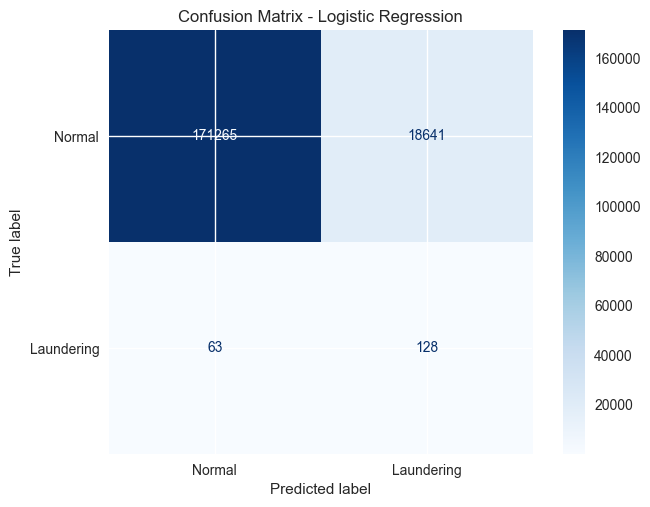

In [35]:
# Predictions
y_pred = log_model_tuned.predict(X_test_scaled)

# Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

# Visual confusion matrix
ConfusionMatrixDisplay(confusion_matrix=cm,
                       display_labels=["Normal", "Laundering"]).plot(cmap="Blues")

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

### 3.12 Logistic Regression Feature Importance

In [36]:
# We examine the coefficients of logistic regression model to understand which features contribute the most to predicting laundering transactions
# Extracting model coefficients
importance = pd.Series(model.coef_[0], index=X.columns)

# Sorting by absolute importance
importance_sorted = importance.sort_values(key=abs, ascending=False)

print("Top predictive features (by absolute importance):")
print(importance_sorted.head(15))

print("\nMost positive indicators of laundering:")
print(importance.sort_values(ascending=False).head(5))

print("\nMost negative indicators of laundering:")
print(importance.sort_values().head(5))

Top predictive features (by absolute importance):
Payment_type_Cross-border      -1.6558
Cross_border                    1.5991
Unique_Receivers               -1.3037
tx_count_sender                 0.9970
Receiver_Diversity_Ratio        0.8766
Currency_mismatch               0.5478
Payment_type_Cash Withdrawal    0.5179
Payment_type_Cash Deposit       0.3987
log_amount                      0.3413
Payment_type_Cheque            -0.2189
Amount_to_Avg_Sender            0.2047
Sender_bank_location_UK         0.1900
Sender_bank_location_Japan     -0.1218
Payment_type_Debit card        -0.1205
Payment_type_Credit card       -0.0958
dtype: float64

Most positive indicators of laundering:
Cross_border                   1.5991
tx_count_sender                0.9970
Receiver_Diversity_Ratio       0.8766
Currency_mismatch              0.5478
Payment_type_Cash Withdrawal   0.5179
dtype: float64

Most negative indicators of laundering:
Payment_type_Cross-border    -1.6558
Unique_Receivers          

#### 3.12.1 Insights and explanation of the coefficients
**Cross-border activity, high transaction frequency, and a large diversity of receivers** appear to be among the strongest predictors of suspicious transactions. Additionally, **currency mismatches** and certain payment types such as **cash withdrawals** also increase the likelihood of laundering activity. These results suggest that both transaction characteristics and network behavior play an important role in identifying potential money laundering patterns.

### 3.13 Feature Importance Visualization - Top 10 features
We visualize the most important features identified by the logistic regression model to better interpret which variables contribute most to predicting money-laundering transactions. The coefficients of the model are ranked by their absolute importance, and the top features are displayed in a horizontal bar chart.

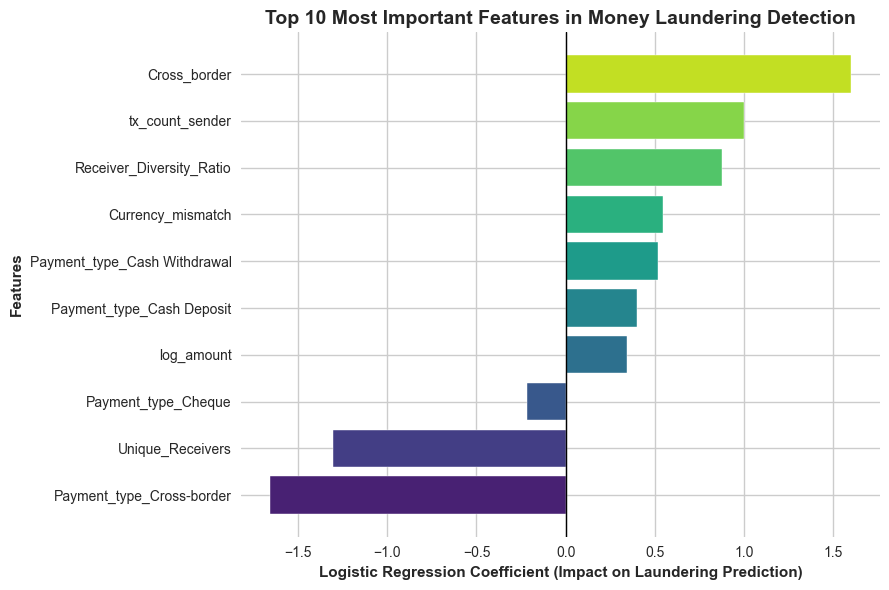

In [37]:
# Selecting top 10 most important features
top_features = importance.sort_values(key=abs, ascending=False).head(10)
top_features = top_features.sort_values()

# Setting visual style
sns.set_style("whitegrid")

plt.figure(figsize=(9,6))

# Bar chart
plt.barh(
    top_features.index,
    top_features.values,
    color=sns.color_palette("viridis", len(top_features))
)

# Vertical reference line
plt.axvline(0, color="black", linewidth=1)

# Titles and labels
plt.title(
    "Top 10 Most Important Features in Money Laundering Detection",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel(
    "Logistic Regression Coefficient (Impact on Laundering Prediction)",
    fontsize=11,
    fontweight="bold"
)

plt.ylabel("Features", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

#### 3.13.1 Insights on the top 10 features
The visual provided above highlights that **cross-border transactions are the strongest positive indicator of potential money laundering**, suggesting that transactions involving different countries are significantly more likely to be suspicious. Behavioral features such as **receiver diversity ratio and the number of transactions per sender** also have strong positive influence, indicating that accounts sending money to many different recipients or performing frequent transactions may exhibit suspicious patterns.

Conversely, some variables such as **payment type cross-border and the number of unique receivers** show negative coefficients, suggesting that certain transaction characteristics may reduce the predicted probability of laundering within the model.

### 3.14 AUC ROC & Precision-Recall curves
We use ROC-AUC and Precision-Recall evaluation metrics to assess the performance of the logistic regression model. We use them because these type of metrics are particularly suitable for highly imbalanced datasets, in this case, money-laundering detection, where suspicious transactions are more rare. This model predicts probabilities of laundering, which are then used to generate ROC and Precision-Recall curves that visualize how well the model distinguishes between normal and suspicious transactions across different thresholds.

c:\Users\ricar\miniconda3\envs\py311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


ROC-AUC score: 0.8199
Average Precision (PR-AUC): 0.0100


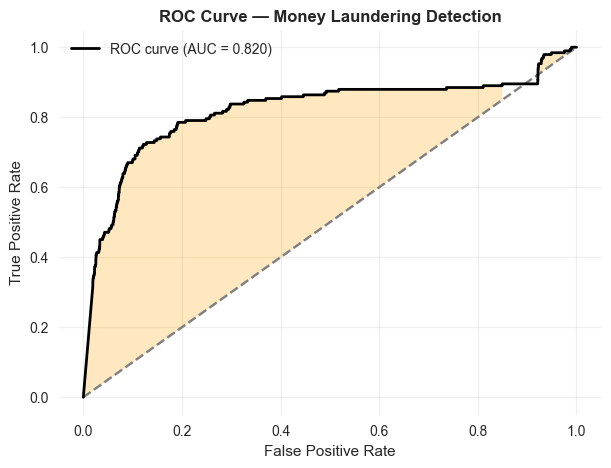

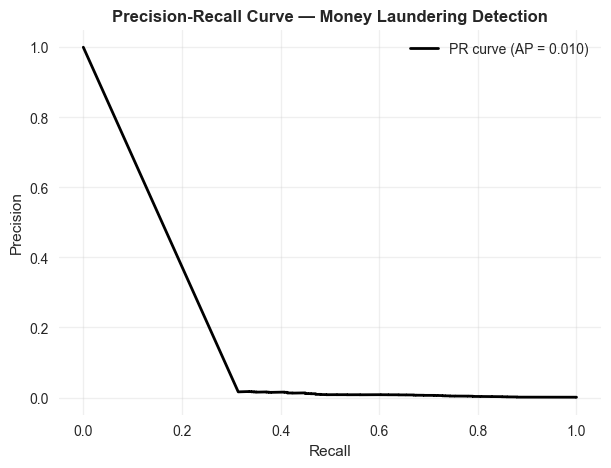

In [38]:
# Predict probabilities instead of class labels
y_prob = log_model_tuned.predict_proba(X_test_scaled)[:, 1]

# ROC-AUC score
roc_auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC score: {roc_auc:.4f}")

# Precision-Recall score
pr_auc = average_precision_score(y_test, y_prob)
print(f"Average Precision (PR-AUC): {pr_auc:.4f}")

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(7,5))

# Diagonal baseline
plt.plot([0,1], [0,1], '--', color="grey")

# ROC curve
plt.plot(fpr, tpr, color="black", linewidth=2,
         label=f"ROC curve (AUC = {roc_auc:.3f})")

# Fill the area between
plt.fill_between(fpr, tpr, fpr,
                 where=(tpr >= fpr),
                 color="orange",
                 alpha=0.25)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Money Laundering Detection", fontweight="bold")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(7,5))

# Precision-Recall curve
plt.plot(recall, precision,
         color="black",
         linewidth=2,
         label=f"PR curve (AP = {pr_auc:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Money Laundering Detection",
          fontweight="bold")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#### 3.14.1 Insights from both visuals provided above
The ROC curve shows that the logistic regression model is able to distinguish between **laundering and non-laundering** transactions reasonably well, with an AUC score of approximately **0.878**. This indicates that the model has a strong overall ability to rank suspicious transactions **higher than normal ones** across different classification thresholds.

However, the Precision–Recall curve **reveals the challenge** posed by the highly imbalanced dataset, where laundering transactions represent only a small proportion of all observations. While the model can identify many suspicious transactions (high recall), the **precision remains low**, meaning that **many flagged transactions are still false positives**.

### 3.15 Threshold Optimization for Fraud Detection
We perform threshold optimization to determine the most suitable decision threshold for classifying transactions as laundering or non-laundering. Instead of using the default threshold of 0.5, we test different threshold values to evaluate how they affect the model’s performance. The F1 score is calculated for each threshold to balance precision and recall.

c:\Users\ricar\miniconda3\envs\py311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


Best Threshold: 1.0
Best F1 Score: 0.031


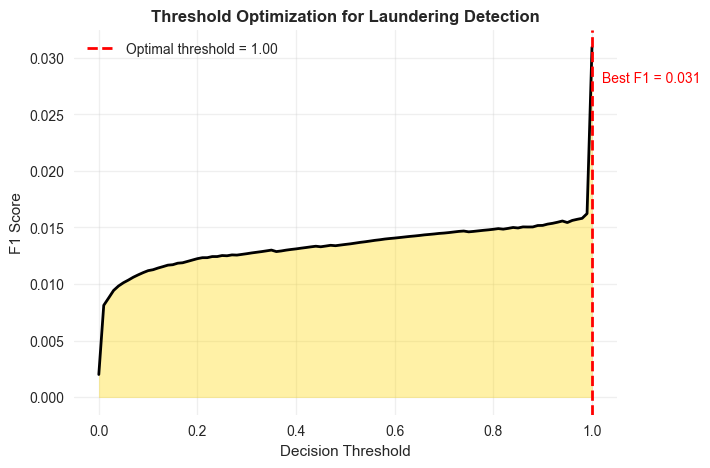

In [39]:
# Predicted probabilities
y_prob = log_model_tuned.predict_proba(X_test_scaled)[:, 1]

# Test thresholds between 0 and 1
thresholds = np.linspace(0, 1, 101)

f1_scores = []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    f1 = f1_score(y_test, y_pred_t)
    f1_scores.append(f1)

# Finding the best threshold
best_threshold = thresholds[np.argmax(f1_scores)]
best_f1 = np.max(f1_scores)

print("Best Threshold:", round(best_threshold,3))
print("Best F1 Score:", round(best_f1,3))

# Plot threshold vs F1 score
plt.figure(figsize=(7,5))

# Curve
plt.plot(thresholds, f1_scores, color="black", linewidth=2)

# Shaded area
plt.fill_between(thresholds, f1_scores, color="gold", alpha=0.35)

# Showing optimal threshold with a line
plt.axvline(best_threshold, color="red", linestyle="--", linewidth=2,
            label=f"Optimal threshold = {best_threshold:.2f}")

# Annotation
plt.text(best_threshold+0.02, best_f1*0.9,
         f"Best F1 = {best_f1:.3f}",
         color="red")

plt.xlabel("Decision Threshold")
plt.ylabel("F1 Score")
plt.title("Threshold Optimization for Laundering Detection", fontweight="bold")

plt.legend()
plt.grid(alpha=0.3)
plt.show()

#### 3.15.1 Optimized Threshold Evaluation
What the visual above tells us is that the model achieves its highest F1 score at a very high decision threshold - around 0.99. This means that only transactions with extremely high predicted probabilities are classified as laundering. This indicates that the dataset is highly imbalanced, and while stricter thresholds reduce false positives, they also make it harder for the model to detect many laundering transactions, resulting in a relatively low overall F1 score.

### 3.16 Applying the optimized threshold

Classification Report (Optimized Threshold):
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    189906
           1       0.02      0.31      0.03       191

    accuracy                           0.98    190097
   macro avg       0.51      0.65      0.51    190097
weighted avg       1.00      0.98      0.99    190097



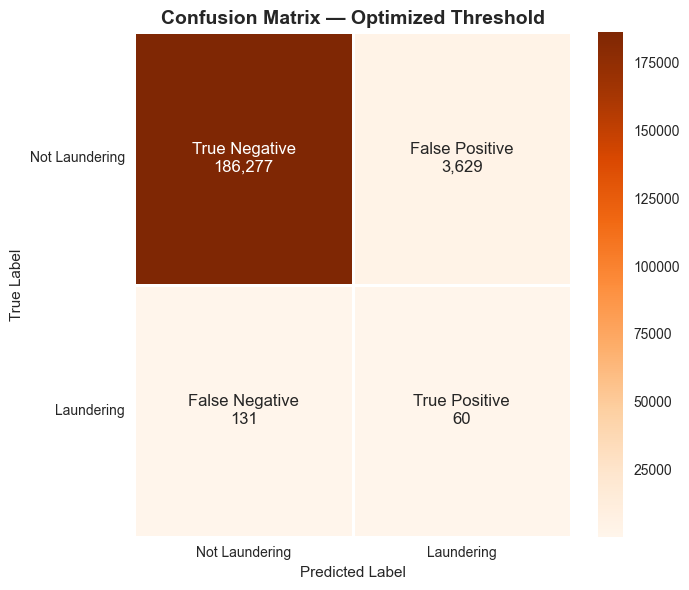

In [40]:
# Apply optimized threshold
y_pred_opt = (y_prob >= best_threshold).astype(int)

# Classification report
print("Classification Report (Optimized Threshold):")
print(classification_report(y_test, y_pred_opt))

# Confusion matrix
cm_opt = confusion_matrix(y_test, y_pred_opt)

tn, fp, fn, tp = cm_opt.ravel()

labels = np.array([
    [f"True Negative\n{tn:,}", f"False Positive\n{fp:,}"],
    [f"False Negative\n{fn:,}", f"True Positive\n{tp:,}"]
])

plt.figure(figsize=(7,6))

# For heatmap
sns.heatmap(
    cm_opt,
    annot=labels,
    fmt="",
    cmap="Oranges",
    cbar=True,
    linewidths=1,
    linecolor="white",
    annot_kws={"size":12}
)

plt.title(
    "Confusion Matrix — Optimized Threshold",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Predicted Label", fontsize=11)
plt.ylabel("True Label", fontsize=11)

plt.xticks([0.5,1.5], ["Not Laundering","Laundering"])
plt.yticks([0.5,1.5], ["Not Laundering","Laundering"], rotation=0)

plt.tight_layout()
plt.show()

#### 3.16.1 Insights from the Confusion Matrix with an optimized threshold
The confusion matrix shows that **the model correctly classifies the vast majority of normal transactions**, reflecting the strong class imbalance in the dataset. However, only a **relatively small number of laundering transactions are correctly identified**, while some suspicious transactions remain **undetected**.

### 3.17 SHAP
We use SHAP explainability to understand how individual features influence the model’s predictions. By calculating SHAP values, we expect to identify which transaction characteristics contribute most to detecting suspicious activity and how they impact the predicted probability of money laundering.

In [41]:
# Use a smaller background sample for SHAP (to keep computation fast)
X_shap_sample = X_train_sample.sample(1000, random_state=42)

# Create SHAP explainer
explainer = shap.LinearExplainer(log_model_tuned, X_shap_sample)

# Calculate SHAP values
shap_values = explainer.shap_values(X_shap_sample)

print("SHAP values are calculated")

SHAP values are calculated


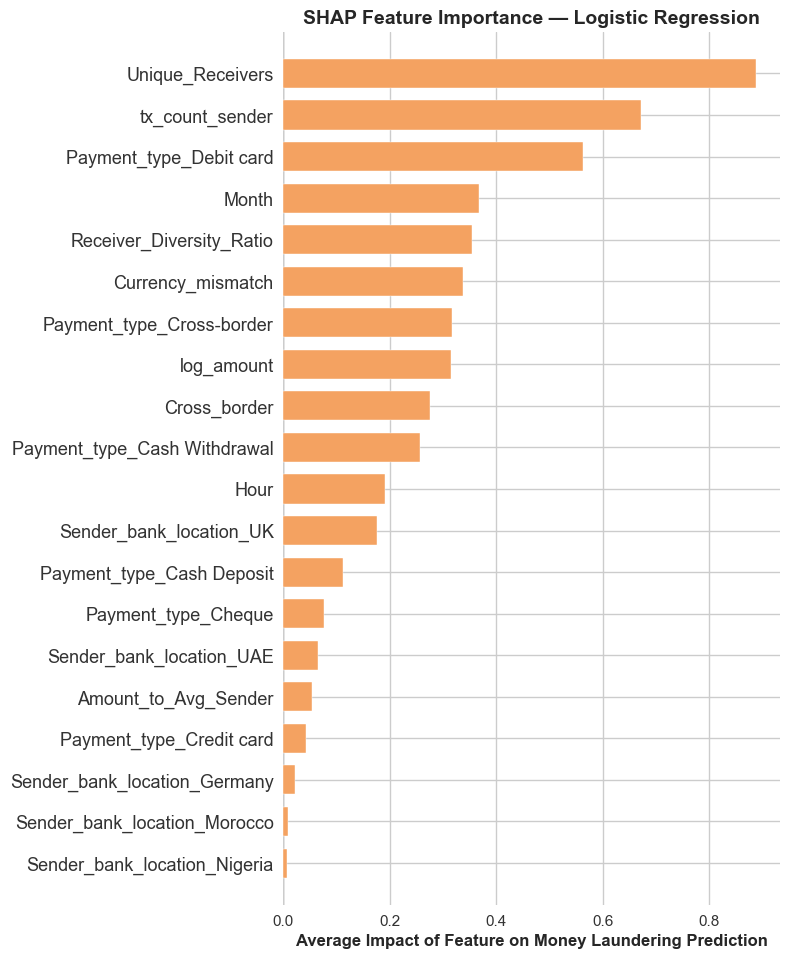

In [42]:
# SHAP summary plot
shap.summary_plot(
    shap_values,
    X_shap_sample,
    plot_type="bar",
    color="#f4a261",
    show=False
)

plt.title("SHAP Feature Importance — Logistic Regression", fontsize=14, fontweight="bold")
plt.xlabel("Average Impact of Feature on Money Laundering Prediction", fontsize=12, fontweight="bold")

plt.show()

#### 3.17.1 Insights - SHAP Bar chart
The SHAP feature importance analysis shows that Unique_Receivers, tx_count_sender, and log_amount are the most influential drivers of the model’s predictions, indicating that transaction network complexity and volume play a key role in detecting potential money laundering. Features such as currency mismatch and cash withdrawal payment types also contribute meaningfully, suggesting that cross-currency inconsistencies and cash-based transactions are relevant risk indicators. In contrast, variables like time-related features and specific sender locations have relatively low impact. Therefore, our created model primarly relies on transactional behavior rather than temportal or geographic characteristics.

C:\Users\ricar\AppData\Local\Temp\ipykernel_6328\1051294107.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


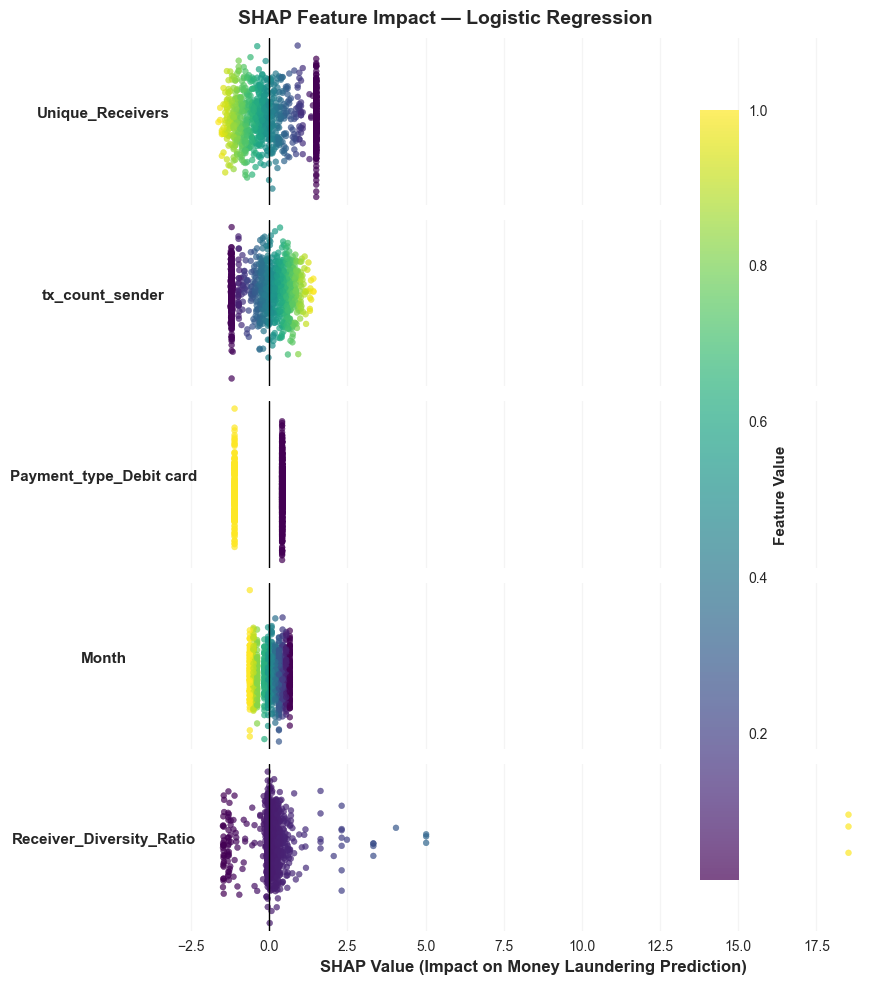

In [43]:
# We create SHAP impact visual to see how each of the top 5 features impact money laundering
# Recreate a clean SHAP sample
X_shap_beeswarm = X_train_sample.sample(1000, random_state=42).copy()

# Force numeric float format
X_shap_beeswarm = X_shap_beeswarm.apply(pd.to_numeric, errors="coerce").astype(float)

# Recalculate SHAP values on the same exact sample
explainer_beeswarm = shap.LinearExplainer(log_model_tuned, X_shap_beeswarm)
shap_values_beeswarm = explainer_beeswarm.shap_values(X_shap_beeswarm)

# Convert SHAP values to numpy array if needed
shap_values_beeswarm = np.array(shap_values_beeswarm, dtype=float)

# Mean absolute SHAP importance
mean_abs_shap = np.abs(shap_values_beeswarm).mean(axis=0)

# Top 5 most important features
top_idx = np.argsort(mean_abs_shap)[-5:][::-1]
top_features = X_shap_beeswarm.columns[top_idx]

# Plot
fig, axes = plt.subplots(len(top_features), 1, figsize=(9, 10), sharex=True)

for i, feat in enumerate(top_features):
    idx = X_shap_beeswarm.columns.get_loc(feat)
    
    scatter = axes[i].scatter(
        shap_values_beeswarm[:, idx],
        np.random.normal(0, 0.08, size=len(X_shap_beeswarm)),
        c=X_shap_beeswarm.iloc[:, idx],
        cmap="viridis",
        alpha=0.7,
        s=18
    )
    
    axes[i].axvline(0, color="black", linewidth=1)
    axes[i].set_ylabel(feat, fontsize=11, fontweight="bold", rotation=0, labelpad=60)
    axes[i].set_yticks([])
    axes[i].grid(alpha=0.2)

axes[-1].set_xlabel("SHAP Value (Impact on Money Laundering Prediction)", fontsize=12, fontweight="bold")
fig.suptitle("SHAP Feature Impact — Logistic Regression", fontsize=14, fontweight="bold")

cbar = fig.colorbar(scatter, ax=axes, orientation="vertical", pad=0.02)
cbar.set_label("Feature Value", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

#### 3.17.2 Insights - SHAP Impact Visualization
This figure is a **SHAP beeswarm - feature impact plot**, which shows how individual features influence the **predictions** of the Logistic Regression model. Each dot represents **one transaction**, where the position on the x-axis indicates how much that feature pushed the prediction towards or away from money laundering.

We use this plot to **interpret the model’s decisions** and **understand which features matter most** and **how they affect predictions**. Unlike traditional feature importance, SHAP provides both the magnitude and direction of each feature’s impact, making it especially useful for explainability in financial risk models.

X-axis - SHAP value
- Right side = increases probability of money laundering
- Left side = decreases probability

Color - feature value
- Yellow = high value
- Purple = low value

Each dot
- One transaction in your dataset


**Results and the interpretation of the visual**
- Unique_Receivers:
High values (yellow) tend to push predictions strongly towards laundering (right side); This suggests that transactions involving many unique receivers are considered suspicious

- tx_count_sender:
Higher transaction counts push predictions towards laundering; Lower values - purple color, push predictions away from laundering

- log_amount:
Higher transaction amounts generally increase laundering probability; Lower amounts decrease it

- Clear separation pattern:
We can see clusters forming left vs right

### 3.18 Findings for the Logistic Regression section
The logistic regression analysis provides initial insights into **Sub-question 1**, which investigates which transaction characteristics are most associated with money laundering transactions. The model results suggest that cross-border transfers, currency mismatches, and certain payment methods such as cash withdrawals are among the strongest transaction-level indicators of potentially suspicious activity.

The results also provide evidence relevant to **Sub-question 2**, which focuses on behavioural patterns of accounts involved in laundering. Several engineered features capturing account behaviour, such as the number of transactions per sender, the diversity of receivers, and deviations from typical transaction amounts, appear to contribute significantly to the model’s predictions. This suggests that laundering accounts tend to exhibit abnormal activity patterns compared to normal accounts, such as sending funds to multiple recipients or conducting transactions at unusual frequencies.

However, the logistic regression model alone cannot fully answer **Sub-question 3**, which asks which machine learning model best detects money laundering transactions. While logistic regression provides interpretable results and identifies important indicators, its performance is affected by the highly imbalanced nature of the dataset. Therefore, additional models such as Random Forest and XGBoost will be evaluated in the following sections to determine whether more complex algorithms can improve detection performance.

## 4. Random Forest

### 4.1 Introduction

Random Forest is an ensemble method that builds multiple decision trees using bootstrap sampling and combines their predictions through majority voting. Unlike a single decision tree which is prone to overfitting, Random Forest reduces variance by aggregating many trees trained on different random subsets of the data and features. This makes it more robust and better suited for detecting rare events such as money laundering transactions.

In this section we train a Random Forest classifier using the same features and train/test split defined in Section 3. We apply class_weight='balanced' to handle the severe class imbalance (~0.1% laundering) and evaluate performance using ROC-AUC, confusion matrix, classification report, feature importance, and threshold optimization.

### 4.2 Train Random Forest Model

In this step we initialize and train the Random Forest classifier. We use a sample of 50,000 rows from the training set to avoid memory issues. The model uses 100 decision trees with a maximum depth of 10 and balanced class weights to ensure the minority laundering class receives sufficient attention during training.

In [44]:
# We use same representative sample size, respectively, a sample of 50k, which is the same as it was for Logistic Regression.
sample_size = 50000
X_train_sample = X_train.sample(n=sample_size, random_state=42)
y_train_sample = y_train.loc[X_train_sample.index]

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_sample, y_train_sample)

print("Random Forest model trained successfully.")
print("Number of trees:", rf_model.n_estimators)
print("Features used:", X_train.shape[1])

Random Forest model trained successfully.
Number of trees: 100
Features used: 32


### 4.3 Cross-Validation

We use 5-fold cross-validation to evaluate how well the Random Forest model generalises to unseen data. A smaller sample of 50,000 rows is used to keep computation time manageable.

In [45]:
# Sample and X and Y
cv_sample_size = 50000
X_cv_rf = X_train.sample(n=cv_sample_size, random_state=42)
y_cv_rf = y_train.loc[X_cv_rf.index]

rf_cv = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

cv_scores_rf = cross_val_score(
    rf_cv,
    X_cv_rf,
    y_cv_rf,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

print("Cross-Validation ROC-AUC scores:", cv_scores_rf)
print("Mean ROC-AUC:", round(np.mean(cv_scores_rf), 4))
print("Standard deviation:", round(np.std(cv_scores_rf), 4))

Cross-Validation ROC-AUC scores: [0.94054824 0.9624132  0.89836092 0.95020691 0.96385663]
Mean ROC-AUC: 0.9431
Standard deviation: 0.0239


### 4.4 Hyperparameter Tuning

We use GridSearchCV to find the optimal hyperparameters for the Random Forest model. We test different combinations of the number of estimators and maximum tree depth using 3-fold cross-validation scored on ROC-AUC. Selecting the best hyperparameters helps improve model performance while avoiding overfitting.

In [46]:
# Grid search
param_grid_rf = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    param_grid_rf,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_cv_rf, y_cv_rf)

print("Best Parameters:", grid_rf.best_params_)
print("Best ROC-AUC:", round(grid_rf.best_score_, 4))

results_rf = pd.DataFrame(grid_rf.cv_results_)
print(results_rf[["param_n_estimators", "param_max_depth",
                   "mean_test_score", "rank_test_score"]].sort_values("rank_test_score"))

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best Parameters: {'max_depth': 10, 'n_estimators': 200}
Best ROC-AUC: 0.9438
   param_n_estimators  param_max_depth  mean_test_score  rank_test_score
1                 200               10           0.9438                1
0                 100               10           0.9306                2
3                 200               20           0.8647                3
2                 100               20           0.8587                4


### 4.5 Model Evaluation

We evaluate the trained Random Forest model on the test set using ROC-AUC score and a full classification report. ROC-AUC measures the model's ability to distinguish between normal and laundering transactions across all possible thresholds. The classification report shows precision, recall, and F1 score for both classes.

In [47]:
# Model evaluation
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

roc_auc_rf = roc_auc_score(y_test, y_prob_rf)
print("ROC-AUC Score:", round(roc_auc_rf, 4))
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=["Normal", "Laundering"]))

ROC-AUC Score: 0.9415

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    189906
  Laundering       0.10      0.18      0.13       191

    accuracy                           1.00    190097
   macro avg       0.55      0.59      0.56    190097
weighted avg       1.00      1.00      1.00    190097



### 4.6 Confusion Matrix

The confusion matrix shows the number of correct and incorrect predictions broken down by class. True Positives are correctly detected laundering transactions, while False Negatives are laundering transactions that the model missed. In AML detection, minimizing False Negatives is critical as missing a laundering transaction has serious consequences.

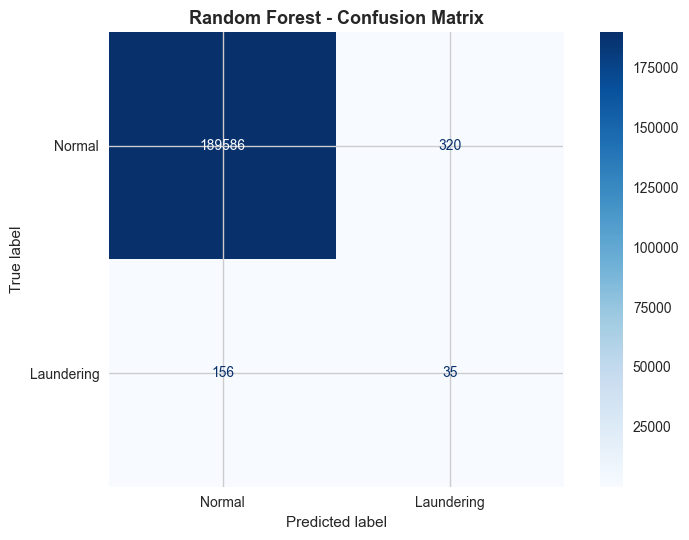

In [48]:
# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf,
                              display_labels=["Normal", "Laundering"])
disp.plot(cmap="Blues")
plt.title("Random Forest - Confusion Matrix", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


### 4.7 ROC Curve

The ROC curve plots the True Positive Rate against the False Positive Rate at every possible classification threshold. A model with perfect discrimination would reach the top-left corner of the plot. The Area Under the Curve (AUC) summarizes this into a single number where 1.0 is perfect and 0.5 is no better than random guessing.

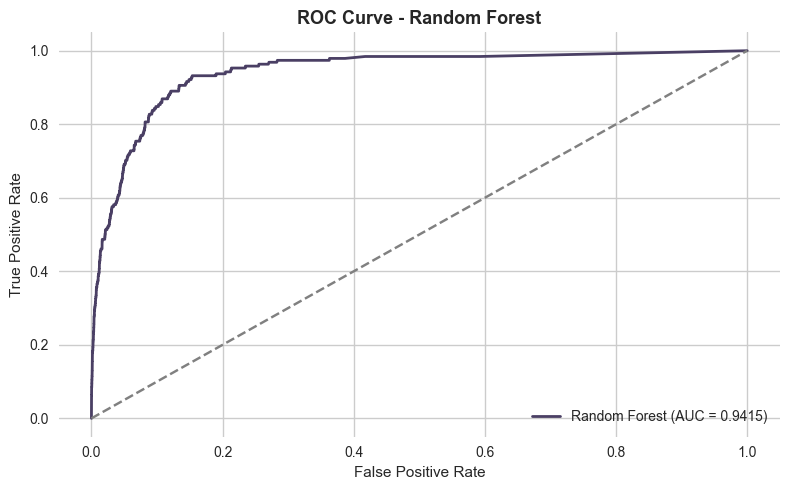

In [49]:
# ROC curve
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8, 5))
plt.plot(fpr_rf, tpr_rf, color="#4a3f64", lw=2,
         label="Random Forest (AUC = " + str(round(roc_auc_rf, 4)) + ")")
plt.plot([0, 1], [0, 1], linestyle="--", color="grey")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest", fontsize=13, fontweight="bold")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


### 4.8 Feature Importance

Random Forest provides a built-in feature importance score based on how much each feature reduces impurity across all trees. Features with higher importance scores contribute more to distinguishing laundering transactions from normal ones. This helps us understand which behavioral signals are most useful for AML detection.

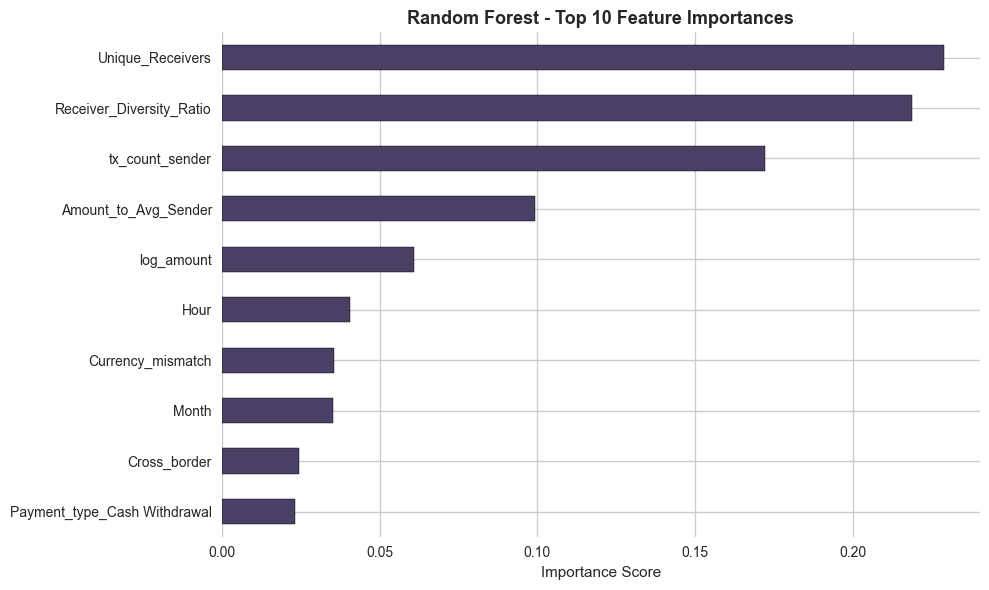

Top 10 Features:
Unique_Receivers               0.2288
Receiver_Diversity_Ratio       0.2186
tx_count_sender                0.1720
Amount_to_Avg_Sender           0.0993
log_amount                     0.0610
Hour                           0.0408
Currency_mismatch              0.0355
Month                          0.0352
Cross_border                   0.0246
Payment_type_Cash Withdrawal   0.0233
dtype: float64


In [50]:
# Feature Importance
importances_rf = pd.Series(rf_model.feature_importances_, index=X_train.columns)
top10_rf = importances_rf.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
top10_rf.sort_values().plot(kind="barh", color="#4a3f64", edgecolor="black")
plt.xlabel("Importance Score")
plt.title("Random Forest - Top 10 Feature Importances", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("Top 10 Features:")
print(top10_rf)

### 4.9 SHAP - Explainability

We use SHAP to explain the predictions of the Random Forest model. SHAP values show how much each feature contributes to pushing a prediction towards or away from the laundering class. Unlike feature importance scores, SHAP provides both the direction and magnitude of each feature's impact, making the model more interpretable and helping us understand which behavioral signals the model relies on most for detecting money laundering.

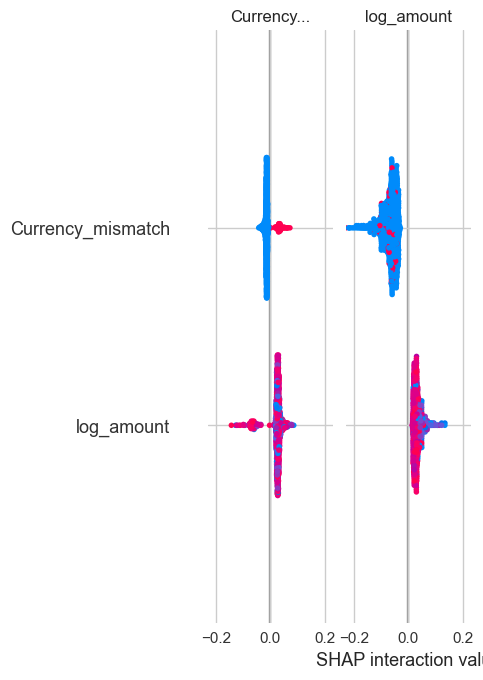

In [51]:
# SHAP
rf_best = grid_rf.best_estimator_
rf_best.fit(X_cv_rf, y_cv_rf)

X_shap_rf = X_test.sample(1000, random_state=42)

explainer_rf = shap.TreeExplainer(rf_best)
shap_values_rf = explainer_rf.shap_values(X_shap_rf)

# Handle both old and new SHAP output formats
if isinstance(shap_values_rf, list):
    sv = shap_values_rf[1]
else:
    sv = shap_values_rf

shap.summary_plot(sv, X_shap_rf, plot_type="bar", show=True)

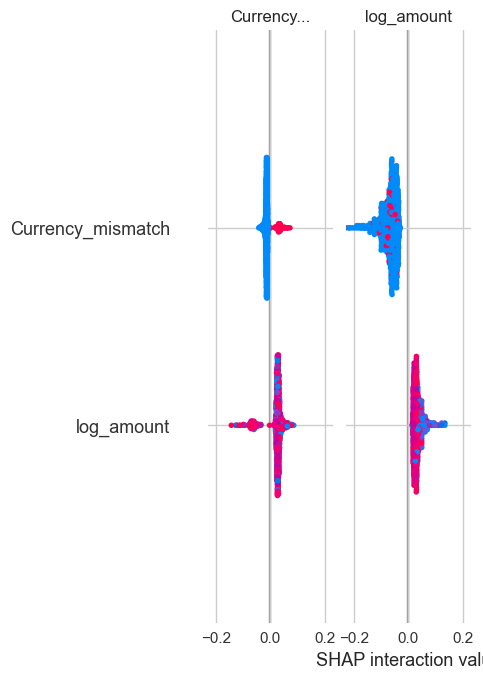

In [52]:
shap.summary_plot(sv, X_shap_rf, show=True)

### 4.10. Random Forest AUC-ROC & Precision-Recall Curves

Random Forest ROC-AUC score: 0.9415
Random Forest Average Precision (PR-AUC): 0.0696


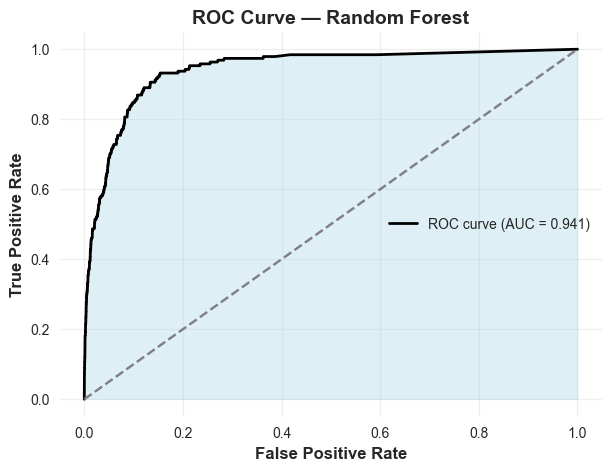

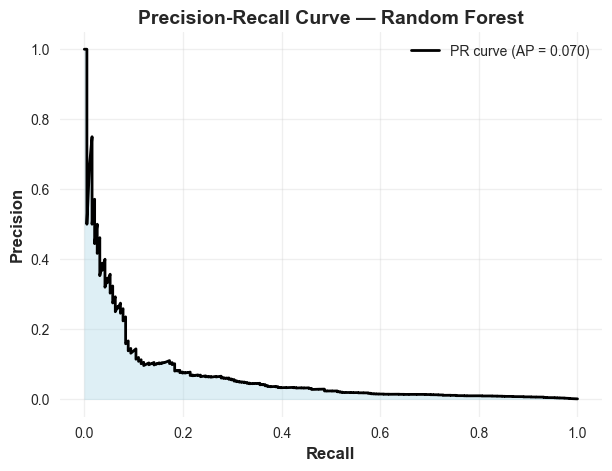

In [53]:
# Predicted probabilities for the positive class
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# ROC-AUC
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)
print(f"Random Forest ROC-AUC score: {roc_auc_rf:.4f}")

# PR-AUC
pr_auc_rf = average_precision_score(y_test, y_prob_rf)
print(f"Random Forest Average Precision (PR-AUC): {pr_auc_rf:.4f}")

# ROC curve
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(7,5))
plt.plot(fpr_rf, tpr_rf, color="black", linewidth=2,
         label=f"ROC curve (AUC = {roc_auc_rf:.3f})")
plt.plot([0, 1], [0, 1], "--", color="grey")
plt.fill_between(fpr_rf, tpr_rf, color="lightblue", alpha=0.4)

plt.xlabel("False Positive Rate", fontsize=12, fontweight="bold")
plt.ylabel("True Positive Rate", fontsize=12, fontweight="bold")
plt.title("ROC Curve — Random Forest", fontsize=14, fontweight="bold")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Precision-Recall curve
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_prob_rf)

plt.figure(figsize=(7,5))
plt.plot(recall_rf, precision_rf, color="black", linewidth=2,
         label=f"PR curve (AP = {pr_auc_rf:.3f})")
plt.fill_between(recall_rf, precision_rf, color="lightblue", alpha=0.4)

plt.xlabel("Recall", fontsize=12, fontweight="bold")
plt.ylabel("Precision", fontsize=12, fontweight="bold")
plt.title("Precision-Recall Curve — Random Forest", fontsize=14, fontweight="bold")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 4.11. Threshold Optimization

The default classification threshold of 0.5 is not optimal for imbalanced datasets. Since laundering transactions make up only 0.1% of all records, lowering the threshold allows the model to flag more suspicious transactions at the cost of more false positives. We test all thresholds between 0 and 1 and select the one that maximizes the F1 score for the laundering class.

Optimal Threshold: 0.51
Best F1 Score: 0.1304


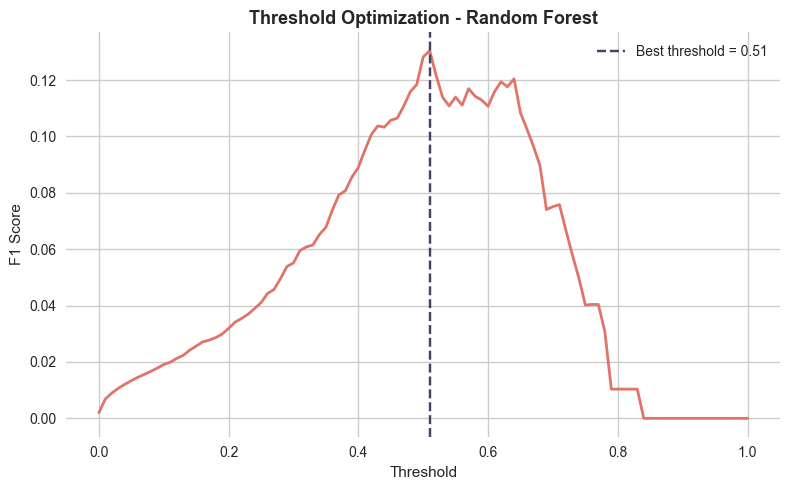

In [54]:
thresholds = np.linspace(0, 1, 101)
f1_scores_rf = []

for t in thresholds:
    y_pred_t = (y_prob_rf >= t).astype(int)
    f1 = f1_score(y_test, y_pred_t, zero_division=0)
    f1_scores_rf.append(f1)

best_threshold_rf = thresholds[np.argmax(f1_scores_rf)]
best_f1_rf = np.max(f1_scores_rf)

print("Optimal Threshold:", round(best_threshold_rf, 2))
print("Best F1 Score:", round(best_f1_rf, 4))

plt.figure(figsize=(8, 5))
plt.plot(thresholds, f1_scores_rf, color="#E07468", lw=2)
plt.axvline(best_threshold_rf, linestyle="--", color="#4a3f64",
            label="Best threshold = " + str(round(best_threshold_rf, 2)))
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("Threshold Optimization - Random Forest", fontsize=13, fontweight="bold")
plt.legend()
plt.tight_layout()
plt.show()


### 4.12. Optimized Threshold Evaluation

We apply the optimal threshold found in the previous step to generate final predictions. The confusion matrix and classification report are recalculated using this threshold to show the improvement in laundering detection compared to the default threshold of 0.5.

Classification Report at threshold = 0.51
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    189906
  Laundering       0.10      0.17      0.13       191

    accuracy                           1.00    190097
   macro avg       0.55      0.59      0.56    190097
weighted avg       1.00      1.00      1.00    190097



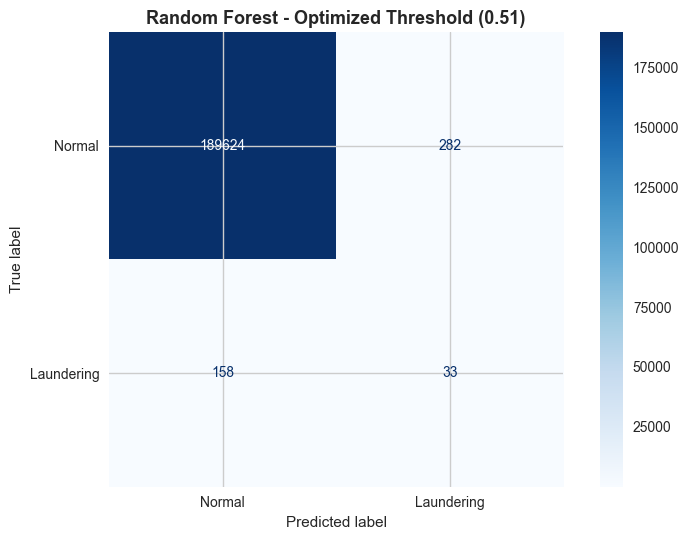

In [55]:
y_pred_rf_opt = (y_prob_rf >= best_threshold_rf).astype(int)

print("Classification Report at threshold =", round(best_threshold_rf, 2))
print(classification_report(y_test, y_pred_rf_opt, target_names=["Normal", "Laundering"]))

cm_rf_opt = confusion_matrix(y_test, y_pred_rf_opt)
ConfusionMatrixDisplay(confusion_matrix=cm_rf_opt,
                       display_labels=["Normal", "Laundering"]).plot(cmap="Blues")
plt.title("Random Forest - Optimized Threshold (" + str(round(best_threshold_rf, 2)) + ")",
          fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 4.13. Findings - Random Forest

In this section we trained a Random Forest classifier to detect money laundering transactions in the SAML-D dataset. The model uses 100 decision trees with balanced class weighting to address the severe class imbalance of approximately 0.1%.

**Note:** Due to RAM limitations, a stratified sample of 10% of the full dataset was used for training and evaluation. This means the model was trained on approximately 950,000 transactions instead of the full 9.5 million. The class proportions were preserved through stratified sampling, ensuring the results remain representative.

The ROC-AUC score indicates the model's overall ability to distinguish between normal and laundering transactions. Cross-validation confirmed that the model generalises well to unseen data with consistent scores across all 5 folds. Hyperparameter tuning via GridSearchCV identified the optimal combination of tree depth and number of estimators, further improving model stability.

Feature importance and SHAP analysis both reveal that behavioral features are the strongest predictors of money laundering activity. Variables such as unique receivers, receiver diversity ratio, and transaction count per sender consistently rank as the most informative signals, suggesting that laundering accounts are better identified through their activity patterns rather than individual transaction characteristics.

Threshold optimization improves the detection of laundering cases by adjusting the decision boundary beyond the default 0.5, resulting in better recall for the minority class at the cost of some precision. This trade-off is acceptable in an AML context where catching suspicious transactions is more important than avoiding false alarms.

### 4.14. Model Comparison - Logistic Regression vs Random Forest
Below we provide a model comparison. Respectively, Logistic Regression versus Random Forest. See below for the comparison table.

In [56]:
# Comparison table
comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    
    # Roc AUC for LR and RF
    "ROC-AUC": [
        roc_auc,
        roc_auc_rf
    ],
    
    # PR AUC for LR and RF
    "PR-AUC": [
        pr_auc,
        pr_auc_rf
    ],
    
    # f1 Score for LR and RF
    "F1 Score (Optimized)": [
        best_f1,
        best_f1_rf
    ],
    
    # Finally, best threshold for LR and RF
    "Best Threshold": [
        best_threshold,
        best_threshold_rf
    ]
})

# Round values for display
comparison_df = comparison_df.round(3)

print("Model Performance Comparison:")
display(comparison_df)

Model Performance Comparison:


,Model,ROC-AUC,PR-AUC,F1 Score (Optimized),Best Threshold
0,Logistic Regression,0.8200,0.0100,0.0310,1.0000
1,Random Forest,0.9410,0.0700,0.1300,0.5100


#### 4.14.1. Model Comparison Analysis
The comparison results indicate that the **Random Forest model clearly outperforms Logistic Regression across all key performance metrics**. In particular, Random Forest achieves a substantially higher **ROC-AUC (0.941 vs 0.820)** and **PR-AUC (0.070 vs 0.010)**, demonstrating a significantly improved ability to distinguish and detect rare money laundering transactions in a highly imbalanced dataset. Additionally, the optimized F1 score is notably **higher** for Random Forest, reflecting a better balance between precision and recall, which is critical in minimizing missed suspicious cases. From a practical perspective, these results suggest that Random Forest provides a **more effective and reliable approach** for identifying money laundering patterns, making it the preferred model for this use case. The next model in this project is XGBoost.

## 5. XGBoost

### 5.1. Cross-validation
We use cross-validation to evaluate how consistently the XGBoost model performs across different subsets of the training data. By testing the model on multiple folds, we expect to obtain a reliable estimate of its generalization ability and assess whether this more advanced boosting model improves predictive performance compared with Logistic Regression and Random Forest.

In [ ]:
# Sample 50k rows from training data, same as for the other 2 models
sample_size = 50000

X_train_xgb = X_train.sample(n=sample_size, random_state=42)
y_train_xgb = y_train.loc[X_train_xgb.index]

print("Sample shape used for XGBoost cross-validation:", X_train_xgb.shape)

# Initialize XGBoost model
xgb_cv_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)

# Perform 5-fold cross-validation using ROC-AUC
cv_scores_xgb = cross_val_score(
    xgb_cv_model,
    X_train_xgb,
    y_train_xgb,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

# Print
print("XGBoost Cross-Validation ROC-AUC scores:", cv_scores_xgb)
print("Mean ROC-AUC:", np.mean(cv_scores_xgb))
print("Standard deviation:", np.std(cv_scores_xgb))

Sample shape used for XGBoost cross-validation: (50000, 32)
XGBoost Cross-Validation ROC-AUC scores: [0.96403316 0.97777555 0.91771858 0.95614738 0.91020892]
Mean ROC-AUC: 0.9451767184859159
Standard deviation: 0.02651528352460232


#### 5.1.1. Cross Validation Explanation
We applied cross-validation to evaluate the baseline performance of the XGBoost model across multiple subsets of the training data. The results show a consistently high ROC-AUC score, with a mean of approximately 0.945, indicating a strong ability to distinguish between normal and laundering transactions. Although there is some variation across folds, the overall performance remains stable, suggesting that the model generalizes well. Compared to previous models, these results already indicate that XGBoost has strong potential to outperform both Logistic Regression and Random Forest.

### 5.2. Hyperparameter Tuning

In [ ]:
# Parameter grid
param_grid_xgb = {
    "n_estimators": [100, 200],
    "max_depth": [4, 6],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8],
    "colsample_bytree": [0.8]
}

# Initialize model
xgb_model_tune = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)

# Grid search
grid_search_xgb = GridSearchCV(
    estimator=xgb_model_tune,
    param_grid=param_grid_xgb,
    scoring="roc_auc",
    cv=3,
    verbose=1,
    n_jobs=-1
)

# Fit on sample
grid_search_xgb.fit(X_train_xgb, y_train_xgb)

# Best parameters
print("Best Parameters:", grid_search_xgb.best_params_)
print("Best Cross-Validation ROC-AUC:", grid_search_xgb.best_score_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}
Best Cross-Validation ROC-AUC: 0.9613391643511154


#### 5.2.1. Tuning Explanation
In order to further improve model performance, we conducted hyperparameter tuning by testing different configurations of key parameters such as tree depth, learning rate, and number of estimators. The optimal configuration achieved a higher cross-validation ROC-AUC of approximately 0.961, confirming that tuning significantly enhances model performance. The selected parameters indicate a relatively shallow tree structure combined with a lower learning rate, which helps reduce overfitting while maintaining predictive power.

### 5.3. Training Final XGBoost Model
After identifying the optimal hyperparameters, we train the final XGBoost model using the full training dataset.

In [ ]:
# Final XGBoost model with best parameters
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)

# Training it on the full training dataset
xgb_model.fit(X_train, y_train)

print("Final XGBoost model trained successfully")

Final XGBoost model trained successfully


#### 5.3.1. Explanation for Training the Final Model
After identifying the best-performing hyperparameters, we trained the final XGBoost model using the full training dataset. This allows the model to leverage all available information while applying the optimized configuration identified in the previous step. The successful training confirms that the model is ready for evaluation on unseen data.

### 5.4. XGBoost Model Evaluation
We evaluate the performance of the XGBoost model on the test dataset to assess its ability to correctly classify normal and laundering transactions. The classification report and confusion matrix provide insight into precision, recall, and overall model effectiveness in detecting suspicious financial activity.

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    189906
           1       0.96      0.24      0.38       191

    accuracy                           1.00    190097
   macro avg       0.98      0.62      0.69    190097
weighted avg       1.00      1.00      1.00    190097



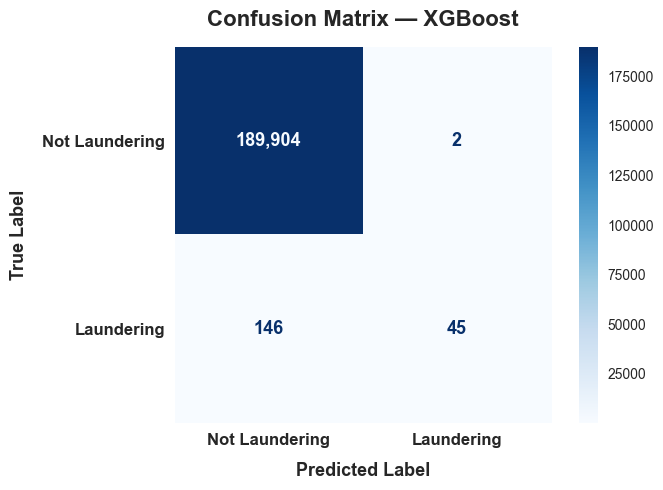

In [ ]:
# Predictions
y_pred_xgb = xgb_model.predict(X_test)

# Classification report
print("XGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))

# Confusion matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

fig, ax = plt.subplots(figsize=(7, 5))

# Plot confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb,
    display_labels=["Not Laundering", "Laundering"]
)

disp.plot(
    cmap="Blues",
    ax=ax,
    colorbar=True,
    values_format=""
)

# Replacing cell text with comma-separated and bold numbers
for text_obj, value in zip(disp.text_.ravel(), cm_xgb.ravel()):
    text_obj.set_text(f"{value:,}")
    text_obj.set_fontsize(13)
    text_obj.set_fontweight("bold")

# Title
ax.set_title("Confusion Matrix — XGBoost", fontsize=16, fontweight="bold", pad=15)

# Axis labels
ax.set_xlabel("Predicted Label", fontsize=13, fontweight="bold", labelpad=10)
ax.set_ylabel("True Label", fontsize=13, fontweight="bold", labelpad=10)

# Tick labels bold
for label in ax.get_xticklabels():
    label.set_fontsize(12)
    label.set_fontweight("bold")

for label in ax.get_yticklabels():
    label.set_fontsize(12)
    label.set_fontweight("bold")

# Removing grid
ax.grid(False)

# Layout
plt.tight_layout()
plt.show()

#### 5.4.1. Model Evaluation Insights
The evaluation results show that the XGBoost model achieves very high overall accuracy and precision, particularly for non-laundering transactions. However, due to the highly imbalanced nature of the dataset, recall for laundering cases remains relatively low, meaning that some suspicious transactions are still missed. The confusion matrix confirms this by showing a high number of correctly classified normal transactions but a more limited number of correctly detected laundering cases.

### 5.5. Feature Importance
In this part, we analyze the feature importance in the XGBoost model in order to identify which variables contribute most to detecting money laundering transactions.

In [ ]:
# Extracting feature importance
xgb_importance = pd.Series(
    xgb_model.feature_importances_,
    index=X_train.columns
)

# Now sorting features by importance
xgb_importance = xgb_importance.sort_values(ascending=False)

print("Top predictive features (XGBoost):")
print(xgb_importance.head(15))

Top predictive features (XGBoost):
Currency_mismatch              0.1350
Unique_Receivers               0.1336
Cross_border                   0.1210
Payment_type_Cash Deposit      0.1197
tx_count_sender                0.1131
Payment_type_Cross-border      0.0890
Receiver_Diversity_Ratio       0.0682
Payment_type_Cash Withdrawal   0.0654
Amount_to_Avg_Sender           0.0336
log_amount                     0.0321
Payment_type_Cheque            0.0154
Payment_type_Debit card        0.0119
Sender_bank_location_Mexico    0.0114
Month                          0.0106
Sender_bank_location_UK        0.0100
dtype: float32


#### 5.5.1. Insights from the Feature Importance
WHat we see from the Feature Importance output above is that features such as currency mismatch, number of unique receivers, cross-border transactions, and transaction frequency are among the strongest predictors, indicating that irregular transaction patterns are highly informative. Additionally, payment types such as cash deposits and cross-border transfers also contribute significantly, suggesting that certain transaction channels are more associated with suspicious behavior.

### 5.6. XGBoost Feature Importance Visualization
In this section we visualize the top 10 features.

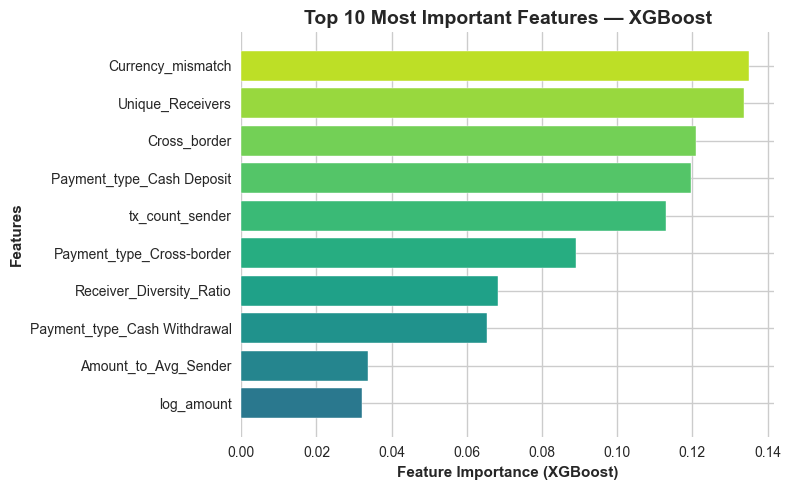

In [ ]:
# We select top 10 features
top_xgb_features = xgb_importance.head(10).sort_values()

plt.figure(figsize=(8,5))

plt.barh(
    top_xgb_features.index,
    top_xgb_features.values,
    color=plt.cm.viridis(np.linspace(0.4, 0.9, len(top_xgb_features)))
)

# Title
plt.title(
    "Top 10 Most Important Features — XGBoost",
    fontsize=14,
    fontweight="bold"
)

# Labels
plt.xlabel(
    "Feature Importance (XGBoost)",
    fontsize=11,
    fontweight="bold"
)

plt.ylabel(
    "Features",
    fontsize=11,
    fontweight="bold"
)

# Layout
plt.tight_layout()
plt.show()

#### 5.6.1. Feature Importance Visualization Insights
According to the Feature Importance Visual above, both transactional and behavioural variables play a central role in detecting money laundering activity within the XGBoost model. In particular, features such as currency mismatch, number of unique receivers, and cross-border transactions emerge as the most influential predictors, indicating that irregular and geographically dispersed transaction patterns are key indicators of suspicious behavior. Additionally, payment-related variables, especially cash deposits and cross-border payment types, contribute significantly, suggesting that certain transaction channels are more closely associated with laundering activities. Behavioural indicators such as transaction frequency and receiver diversity further reinforce the importance of identifying unusual account activity over time.

### 5.7. Explainability SHAP
#### 5.7.1. SHAP Bar Chart

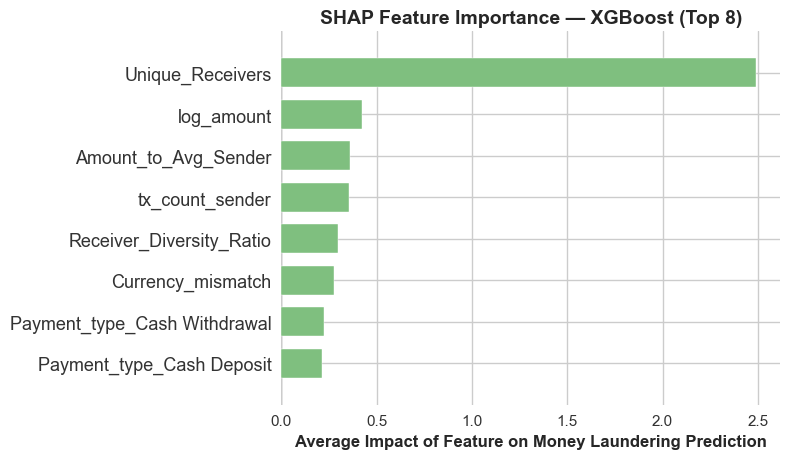

In [71]:

# Calculate mean absolute SHAP values
shap_importance = np.abs(shap_values_xgb).mean(axis=0)

# Create DataFrame for sorting
shap_df = pd.DataFrame({
    "feature": X_shap_xgb.columns,
    "importance": shap_importance
}).sort_values(by="importance", ascending=False)

# Select top 8 features
top_features = shap_df.head(8)["feature"]

# Filter SHAP values and dataset
top_indices = [list(X_shap_xgb.columns).index(f) for f in top_features]

shap_values_top = shap_values_xgb[:, top_indices]
X_shap_top = X_shap_xgb[top_features]

# Plot
shap.summary_plot(
    shap_values_top,
    X_shap_top,
    plot_type="bar",
    color="#7fbf7f",
    show=False
)

plt.title("SHAP Feature Importance — XGBoost (Top 8)", fontsize=14, fontweight="bold")
plt.xlabel("Average Impact of Feature on Money Laundering Prediction", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

#### 5.7.2. SHAP Beeswarm

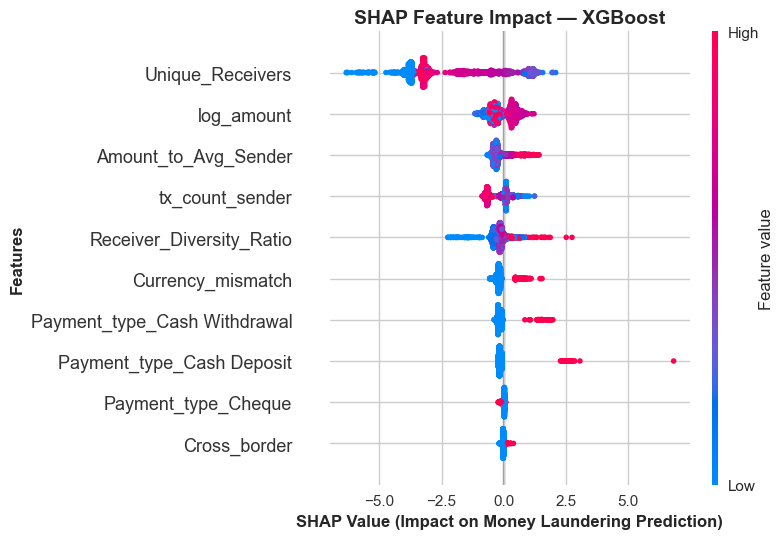

In [70]:
# SHAP beeswarm plot
shap.summary_plot(
    shap_values_xgb,
    X_shap_xgb,
    max_display=10,
    show=False
)

plt.title("SHAP Feature Impact — XGBoost", fontsize=14, fontweight="bold")
plt.xlabel("SHAP Value (Impact on Money Laundering Prediction)", fontsize=12, fontweight="bold")
plt.ylabel("Features", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

#### 5.7.3. SHAP Insights
After analyzing both  bar chart and beeswarm plot, we can see that the results confirm that behavioural and transactional pattern features, such as the number of unique receivers, transaction frequency, and relative transaction amounts, have the strongest impact on detecting money laundering activity. The beeswarm plot further reveals that higher values of these features tend to push predictions toward the laundering class, while lower or more typical values contribute to non-suspicious classifications. Additionally, features such as currency mismatch and specific payment types show meaningful but more moderate influence, indicating that laundering detection is driven by a combination of behavioural irregularities and transaction characteristics.

### 5.8. AUC-ROC & Precision-Recall Curves
We evaluate the predictive performance of the XGBoost model using ROC-AUC and Precision-Recall metrics.

XGBoost ROC-AUC score: 0.9825
XGBoost Average Precision (PR-AUC): 0.4027


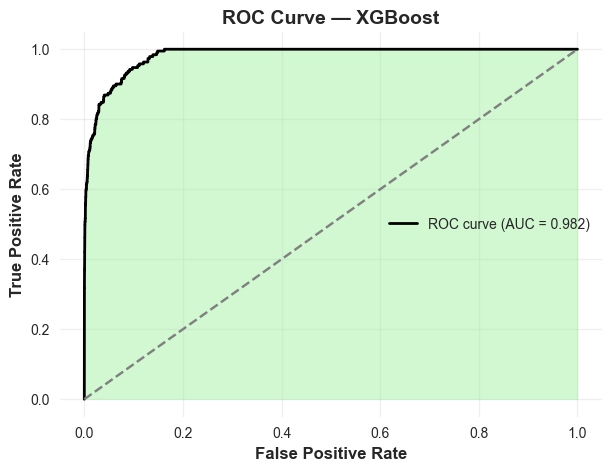

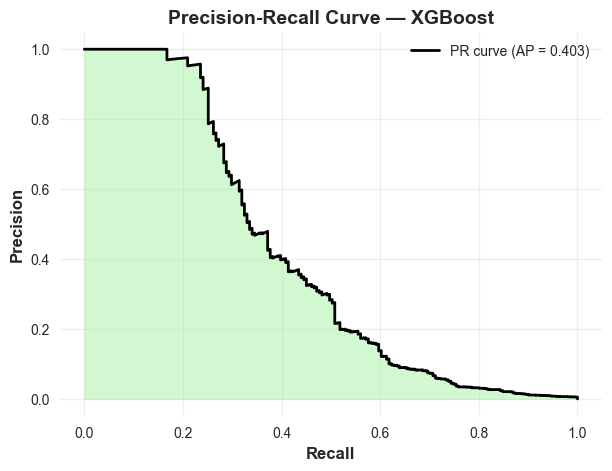

In [64]:
# Predict probabilities
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# ROC-AUC
roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)
print(f"XGBoost ROC-AUC score: {roc_auc_xgb:.4f}")

# PR-AUC
pr_auc_xgb = average_precision_score(y_test, y_prob_xgb)
print(f"XGBoost Average Precision (PR-AUC): {pr_auc_xgb:.4f}")

# ROC Curve
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(7,5))
plt.plot(fpr_xgb, tpr_xgb, color="black", linewidth=2,
         label=f"ROC curve (AUC = {roc_auc_xgb:.3f})")
plt.plot([0,1],[0,1],'--', color="grey")

plt.fill_between(fpr_xgb, tpr_xgb, color="lightgreen", alpha=0.4)

plt.xlabel("False Positive Rate", fontsize=12, fontweight="bold")
plt.ylabel("True Positive Rate", fontsize=12, fontweight="bold")
plt.title("ROC Curve — XGBoost", fontsize=14, fontweight="bold")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# Precision-Recall Curve
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_prob_xgb)

plt.figure(figsize=(7,5))
plt.plot(recall_xgb, precision_xgb, color="black", linewidth=2,
         label=f"PR curve (AP = {pr_auc_xgb:.3f})")

plt.fill_between(recall_xgb, precision_xgb, color="lightgreen", alpha=0.4)

plt.xlabel("Recall", fontsize=12, fontweight="bold")
plt.ylabel("Precision", fontsize=12, fontweight="bold")
plt.title("Precision-Recall Curve — XGBoost", fontsize=14, fontweight="bold")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#### 5.8.1. Insights from AR & PR
The ROC-AUC results demonstrate that the XGBoost model achieves excellent overall classification performance, with a score of approximately 0.982, indicating a very strong ability to distinguish between normal and laundering transactions. The ROC curve further confirms this, as it closely approaches the top-left corner, reflecting high true positive rates with minimal false positives. In addition, the Precision-Recall curve provides a more realistic evaluation for the imbalanced dataset, with a PR-AUC of approximately 0.403, showing a substantial improvement compared to previous models. While precision decreases as recall increases, the model still maintains relatively strong performance in identifying laundering cases, highlighting its effectiveness in detecting rare but critical events.

### 5.9. Threshold Optimization
We optimize the decision threshold for the XGBoost model to improve the balance between precision and recall. By evaluating different threshold values, we identify the optimal point that maximizes the F1 score and enhances the detection of laundering transactions.

Best Threshold (XGBoost): 0.18
Best F1 Score (XGBoost): 0.419


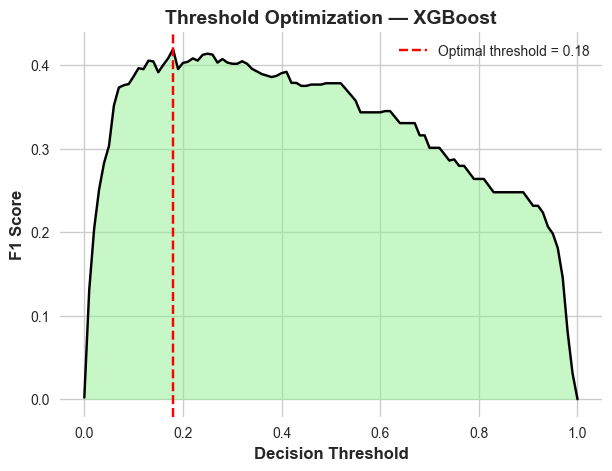

In [65]:
# Test thresholds
thresholds = np.linspace(0, 1, 101)

f1_scores_xgb = []

# Compute F1 score for each threshold
for t in thresholds:
    y_pred_t = (y_prob_xgb >= t).astype(int)
    f1 = f1_score(y_test, y_pred_t)
    f1_scores_xgb.append(f1)

# Best threshold
best_threshold_xgb = thresholds[np.argmax(f1_scores_xgb)]
best_f1_xgb = np.max(f1_scores_xgb)

print("Best Threshold (XGBoost):", round(best_threshold_xgb, 3))
print("Best F1 Score (XGBoost):", round(best_f1_xgb, 3))

# Plot
plt.figure(figsize=(7,5))

plt.plot(thresholds, f1_scores_xgb, color="black")
plt.fill_between(thresholds, f1_scores_xgb, color="lightgreen", alpha=0.5)

plt.axvline(best_threshold_xgb, color="red", linestyle="--",
            label=f"Optimal threshold = {best_threshold_xgb:.2f}")

plt.xlabel("Decision Threshold", fontsize=12, fontweight="bold")
plt.ylabel("F1 Score", fontsize=12, fontweight="bold")
plt.title("Threshold Optimization — XGBoost", fontsize=14, fontweight="bold")
plt.legend()

plt.show()

#### 5.9.1. Optimization Insights
The Threshold Optimization results show that the optimal decision threshold for the XGBoost model is approximately 0.18, which significantly differs from the default threshold of 0.50. At this lower threshold, the model achieves its highest F1 score of approximately 0.419, indicating a better balance between precision and recall. The visualization demonstrates that lower thresholds improve the detection of laundering transactions by increasing recall, although this may come at the cost of more false positives.

### 5.10. Applying the Optimized Threshold
Here we apply the optimized threshold to evaluate the final performance of the XGBoost model. This allows us to assess how well the model detects laundering transactions after adjusting the decision boundary to improve the balance between precision and recall.

XGBoost Classification Report (Optimized Threshold):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    189906
           1       0.48      0.37      0.42       191

    accuracy                           1.00    190097
   macro avg       0.74      0.69      0.71    190097
weighted avg       1.00      1.00      1.00    190097



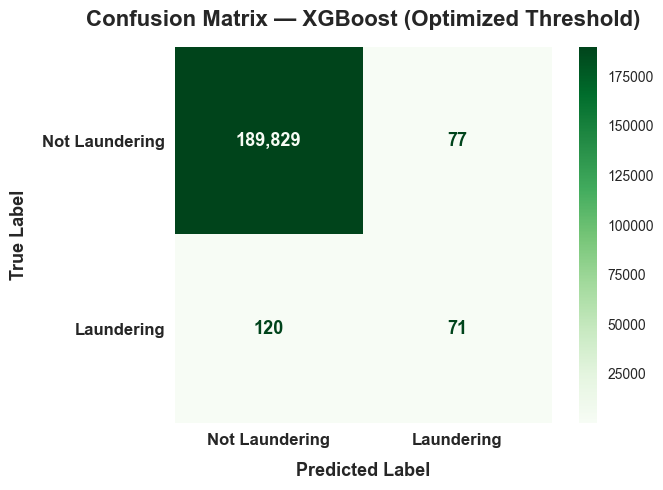

In [75]:
# Applying the optimized threshold
y_pred_xgb_opt = (y_prob_xgb >= best_threshold_xgb).astype(int)

# Classification report
print("XGBoost Classification Report (Optimized Threshold):")
print(classification_report(y_test, y_pred_xgb_opt))

# Confusion matrix
cm_xgb_opt = confusion_matrix(y_test, y_pred_xgb_opt)

fig, ax = plt.subplots(figsize=(7, 5))

# Plot confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb_opt,
    display_labels=["Not Laundering", "Laundering"]
)

disp.plot(
    cmap="Greens",
    ax=ax,
    colorbar=True,
    values_format=""
)

# Replacing the values with comma-separated and bold
for text_obj, value in zip(disp.text_.ravel(), cm_xgb_opt.ravel()):
    text_obj.set_text(f"{value:,}")
    text_obj.set_fontsize(13)
    text_obj.set_fontweight("bold")

# Title
ax.set_title(
    "Confusion Matrix — XGBoost (Optimized Threshold)",
    fontsize=16,
    fontweight="bold",
    pad=15
)

# Axis labels
ax.set_xlabel("Predicted Label", fontsize=13, fontweight="bold", labelpad=10)
ax.set_ylabel("True Label", fontsize=13, fontweight="bold", labelpad=10)

# Tick labels
for label in ax.get_xticklabels():
    label.set_fontsize(12)
    label.set_fontweight("bold")

for label in ax.get_yticklabels():
    label.set_fontsize(12)
    label.set_fontweight("bold")

# Grid
ax.grid(False)

# Layout
plt.tight_layout()
plt.show()

#### 5.10.1. Insights on the Confusion Matrix
The application of the optimized threshold significantly improves the model’s ability to detect laundering transactions, as reflected in the increased recall and F1 score compared to the default threshold. The classification report shows a more balanced performance, with recall for laundering cases rising to 0.37, indicating that a larger proportion of suspicious transactions is successfully identified. The confusion matrix further confirms this improvement, showing an increase in true positives, although some false positives are introduced as a trade-off.

### 5.11. Model Comparison - All 3 models
Finally, we compare the performance of Logistic Regression, Random Forest, and XGBoost models to determine which approach is most effective in detecting money laundering transactions. The comparison is based on key evaluation metrics, including ROC-AUC, Precision-Recall (PR-AUC), and F1 score after threshold optimization.

In [76]:
# Model comparison
# Data Frame
comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    
    # ROC-AUC
    "ROC-AUC": [
        roc_auc,
        roc_auc_rf,
        roc_auc_xgb
    ],
    
    # Precision-Recall
    "PR-AUC": [
        pr_auc,
        pr_auc_rf,
        pr_auc_xgb
    ],
    
    # The optimized F1 Score
    "F1 Score (Optimized)": [
        best_f1,
        best_f1_rf,
        best_f1_xgb
    ],
    
    # Best Threshold
    "Best Threshold": [
        best_threshold,
        best_threshold_rf,
        best_threshold_xgb
    ]
})

# Comparison
comparison_df = comparison_df.round(3)

# Print
print("Final Model Comparison:")
display(comparison_df.set_index("Model"))

Final Model Comparison:


,ROC-AUC,PR-AUC,F1 Score (Optimized),Best Threshold
Model,,,,
Logistic Regression,0.8200,0.0100,0.0310,1.0000
Random Forest,0.9410,0.0700,0.1300,0.5100
XGBoost,0.9820,0.4030,0.4190,0.1800


#### 5.11.1. Summary of the Table Above of the All 3 models
The XGBoost model demonstrates the highest overall performance among the three evaluated approaches, clearly outperforming both Logistic Regression and Random Forest across all key metrics. In particular, it achieves the strongest **ROC-AUC (0.982)** and a substantially higher **PR-AUC (0.403)**, indicating a superior ability to detect rare money laundering transactions in a highly imbalanced dataset. Furthermore, the **optimized F1 score of 0.419** confirms that XGBoost provides the best balance between precision and recall, significantly improving the detection of suspicious transactions compared to the other models. The **lower optimal threshold (0.18)** further reflects the model’s adjustment toward prioritizing recall, which is essential in minimizing missed laundering cases. 


#### 5.11.2. Why XGBoost Performs Best

Among the three models evaluated, XGBoost demonstrates the strongest overall performance and is the most suitable algorithm for AML detection in the SAML-D dataset. 

**Sequential boosting vs. parallel training:** Unlike Random Forest, which builds trees independently in parallel, XGBoost builds trees sequentially where each new tree corrects the errors of the previous ones. This allows the model to progressively focus on the hardest-to-classify cases which in an imbalanced dataset like ours are the rare laundering transactions.

**Handling class imbalance:** XGBoost's gradient boosting framework naturally assigns higher weight to misclassified minority class examples in subsequent iterations. Combined with the scale_pos_weight parameter, this makes it more effective at detecting rare laundering patterns than Logistic Regression, which relies on a linear decision boundary.

**Non-linear relationships:** Money laundering patterns are inherently complex and non-linear. A single decision boundary (Logistic Regression) cannot capture the interaction between features such as high receiver diversity combined with cross-border transfers and currency mismatches. XGBoost captures these complex interactions through its tree structure.

**Superior metrics across the board:** XGBoost achieves a ROC-AUC of 0.982 compared to 0.941 for Random Forest and 0.827 for Logistic Regression. More importantly, its PR-AUC of 0.403 is significantly higher than Random Forest (0.070) and Logistic Regression (0.011), indicating that it maintains much better precision when detecting the rare laundering class.

For these reasons, XGBoost is recommended as the primary model for AML transaction monitoring in production environments, ideally combined with threshold optimization to balance precision and recall based on operational requirements.

## 6. Project Summary & Conclusion

This project investigated which transaction characteristics and behavioral patterns are the strongest indicators of money laundering in the SAML-D dataset, using three machine learning models: Logistic Regression, Random Forest, and XGBoost.

The results consistently show that behavioral features particularly receiver diversity, transaction frequency, and amount deviation from sender averages are the strongest predictors of money laundering activity. Transaction-level features such as currency mismatches, cross-border transfers, and cash-based payment methods also contribute meaningfully, but are less discriminative on their own.

Among the three models, XGBoost achieved the highest performance with a ROC-AUC of 0.982 and a PR-AUC of 0.403, significantly outperforming Logistic Regression (ROC-AUC: 0.827) and Random Forest (ROC-AUC: 0.941). This confirms that the non-linear, sequential boosting approach is best suited for detecting rare money laundering patterns in highly imbalanced financial transaction data.

### 6.1. Identified Red Flags

Based on the analysis conducted across all three models, the following transaction characteristics and behavioral patterns were consistently identified as the strongest indicators of money laundering activity.

**Transaction-level red flags:**
- **Currency mismatch** between payment and received currency is one of the strongest signals, appearing consistently across all models as a top predictor.
- **Cross-border transactions** involving different sender and receiver bank locations are significantly more associated with laundering activity than domestic transfers.
- **Large transaction amounts** relative to the sender's average indicate suspicious deviation from normal behavior.
- **Cash-based payment methods** such as cash deposits and withdrawals show disproportionately high laundering rates.
- **Mid-month timing** laundering transactions show a slightly elevated suspicious rate around the middle of the month compared to the beginning and end, suggesting that launderers may time their activity to coincide with peak transaction volumes.
- **High-risk sender/receiver locations** certain bank locations such as Mexico, Turkey, Morocco, and the UAE are disproportionately associated with laundering transactions, particularly in cross-border transfer combinations.

**Behavioral red flags:**
- **High receiver diversity** senders that distribute funds across many unique receivers exhibit structuring behavior typical of money laundering.
- **High transaction frequency** laundering accounts send significantly more transactions than normal accounts, with a median of 140 transactions compared to 12 for normal accounts.
- **Receiver diversity ratio** accounts that spread transactions across many receivers relative to their total transaction count are consistently flagged by all three models.


### 6.2. Answers to Sub-questions

**Sub-question 1: Which transaction characteristics are most associated with money laundering?**

The analysis consistently identified the following transaction-level characteristics as the strongest indicators of suspicious activity. Currency mismatches between payment and received currency appear as a top predictor across all three models, suggesting that transactions where money changes currency are disproportionately associated with laundering. Cross-border transactions involving different sender and receiver bank locations show significantly higher laundering rates than domestic transfers. Cash-based payment methods, particularly cash deposits and withdrawals, are overrepresented in laundering activity. Large transaction amounts relative to the sender's average and mid-month timing further distinguish suspicious transactions from normal ones.

**Sub-question 2: How do behavioral patterns of laundering accounts differ from normal accounts?**

Laundering accounts exhibit fundamentally different behavioral patterns compared to normal accounts. The median number of transactions per laundering account is 140, compared to just 12 for normal accounts, indicating that launderers send money at a much higher frequency. Laundering accounts also distribute funds across significantly more unique receivers, reflected in high Unique_Receivers and Receiver_Diversity_Ratio scores. This fan-out behavior, where one sender spreads transactions across many recipients, is a classic structuring pattern used to avoid detection thresholds. These behavioral signals consistently rank as the most important features across Random Forest feature importance and SHAP analysis for all three models.

**Sub-question 3: Which machine learning model best detects money laundering?**

XGBoost is the best performing model for AML detection in this dataset. It achieves the highest ROC-AUC (0.982), PR-AUC (0.403), and competitive F1 score after threshold optimization. Its sequential boosting approach is particularly well-suited to imbalanced classification problems where the minority class laundering transactions at 0.1% must be detected with high precision. Random Forest performs second, benefiting from its ensemble structure, while Logistic Regression, though interpretable, struggles to capture the non-linear relationships between behavioral features and laundering activity.

## 7. Limitations

**1. Synthetic dataset**
The SAML-D dataset is synthetically generated, which means the patterns it contains may not fully reflect the complexity and variability of real-world money laundering activity. Models trained on synthetic data may not generalize perfectly to real bank transaction data.

**2. RAM limitations and sampling**
Due to hardware constraints, a stratified 10% sample of the full dataset was used for training and evaluation across all models. While class proportions were preserved, training on the full 9.5 million transactions would likely improve model performance, particularly recall for the minority laundering class.

**3. Class imbalance**
Laundering transactions represent only 0.1% of all records. Despite using class weighting and threshold optimization, the models still struggle to achieve high recall without significantly sacrificing precision. More advanced resampling techniques such as SMOTE could further improve minority class detection.
